<a href="https://colab.research.google.com/github/formacionCDIA/cursoCDIA/blob/main/Notebooks/6_Modelo_regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Análisis de datos y aprendizaje automático**
---

# **6. Modelos de regresión**

A diferencia de la clasificación, donde la salida del modelo es una categoría, en regresión el objetivo es predecir un valor continuo. Por ejemplo:

* Estimar el precio de una vivienda según sus características.
* Calcular el nivel de glucosa en sangre a partir de variables clínicas.
* Predecir la temperatura en función de datos meteorológicos previos.

En todos estos casos, el modelo aprende a partir de datos etiquetados, pero en vez de etiquetas como “sí/no” o “Excelente/Regular/Malo”, las salidas deseadas son números reales.


## 🎯 Regresión lineal y mínimos cuadrados

La regresión lineal es uno de los modelos más sencillos y clásicos del aprendizaje supervisado. Su objetivo es encontrar una relación lineal entre una o más variables independientes o predictoras ($X$) y una variable dependiente o respuesta ($Y$).

$$
\hat{y} = \mathbf{w}^\top \mathbf{x} + b = \sum_{i=1}^{p} w_i x_i + b
$$

- $\hat{y} $: predicción del modelo (se lee "y sombrero").
- $x_i$: i-ésima característica (variable de entrada o predictor).
- $w_i$: peso aprendido para la característica $x_i$.
- $b$: término independiente o sesgo (**bias**). Es la ordenada en el origen, se corresponde con el valor promedio de la variable respuesta cuando todos los predictores son cero.
- $\sum\limits_i\limits^p w_i x_i$: suma ponderada de las características, es decir, que tanto influye cada variable en la predicción.


Se entiende como regresión lineal simple, a la que define la relación entre una variable independiente (p=1) y una variable dependiente mediante una línea recta. De lo contrario, si se define la relación entre más de una variable independiente (p>1) y una variable dependiente se habla de regresión lineal múltiple.


**Ajustar el modelo** consiste en estimar, a partir de los datos disponibles, los valores de los coeficientes de regresión que maximizan la verosimilitud (likelihood), es decir, los que dan lugar al modelo que con mayor probabilidad puede haber generado los datos observados.



### 🥇 Problema de regresión
Empecemos con un ejemplo de **regresión lineal múltiple**, en el que el modelo debe predecir un **valor numérico continuo**. En este ejercicio, entrenaremos un modelo para estimar el **precio de una vivienda**.

A diferencia del ejemplo de la notebook de modelo de clasificación, aquí aplicaremos más preprocesamiento de los datos antes de crear el modelo.


#### Recolección de datos

**Contexto**

Este es el conjunto de datos utilizado en libro de Aurélien Géron, "Aprendizaje automático práctico con Scikit-Learn y TensorFlow". Sirve como una excelente introducción a la implementación de algoritmos de aprendizaje automático, ya que requiere una limpieza de datos rudimentaria, tiene una lista de variables fácil de entender y su tamaño óptimo es ideal.
Los datos contienen información del censo de California, Estados Unidos, de 1990.


**Objetivo del modelo**

Predecir los precios medianos de las viviendas en los distritos de California derivados del censo de 1990.


**Diccionario de datos**

Los datos corresponden a las viviendas  de California y a un resumen estadístico basado en el censo de 1990 que tiene en cuenta la casa dentro de distritos. Tenga en cuenta que los datos no están depurados, por lo que requieren preprocesamiento. Las columnas son las siguientes:

* **longitude (longitud)**: Indica la distancia al oeste de una casa; un valor más alto indica que está más al oeste.

* **latitude (latitud)**: Indica la distancia al norte de una casa; un valor más alto indica que está más al norte.

* **housing_median_age (edad mediana de la Vivienda)**: Edad mediana de una casa dentro de un distrito; un valor más bajo indica una construcción más nueva.
* **total_rooms (habitaciones Totales)**: Número total de habitaciones dentro de un distrito.

* **total_bedrooms(dormitorios Totales)**: Número total de dormitorios dentro de un distrito.

* **population (población)**: Número total de personas que residen en un distrito.

* **households (hogares)**: Número total de hogares, un grupo de personas que residen dentro de una unidad de vivienda, para un distrito.

* **median_income (ingresos medianos)**: Ingresos mediano de los hogares dentro de distrito (medidos en decenas de miles de dólares estadounidenses).

* **median_house_value (valor mediano de la casa)**: Valor mediano de la casa para los hogares dentro de un distrito(medido en dólares estadounidenses).

* **ocean_proximity (proximidad al Océano)**: Ubicación de la casa con respecto al océano/mar.

[Informacion del conjunto de datos](https://www.kaggle.com/datasets/camnugent/california-housing-prices)


In [ ]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'

nombre_archivo = 'housing.csv'

ruta_archivo = url_base + nombre_archivo # Especificar ruta de archicvo csv

housing_df = pd.read_csv(ruta_archivo)

In [ ]:
housing_df.head(4) # Primeras 4 filas

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY


In [ ]:
housing_df.shape # Forma (filas, columnas)

(20640, 10)

In [ ]:
housing_df.info() # Informar resumen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
housing_df.columns # Validar columnas

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

* Se identifican **10 características o variables** sobre las viviendas de californias. Cada fila, muestra o instancia representa un distrito. **20640 distritos**.

Un distrito puede ser una zona específica dentro de una ciudad, municipio o provincia, y se utiliza para facilitar la administración del censo y la posterior análisis de los resultados.

* La variable objetivo o respuesta, salida esperada del modelo, ($y$) es **median_house_value**.
* Las características a utilizar o entradas posibles del modelo ($x$) son:[*'longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income',        'ocean_proximity'*]
* El atributo *total_bedrooms* solo tiene 20433 valores no nulos, lo
que significa que 207 distritos no cuentan con valores.
* Todos los atributos son numéricos, excepto *ocean_proximity*. Su tipo es objeto, por lo que podría contener cualquier tipo de objeto de Python, ¿textos? ¿categorías?.

#### Análisis exploratorio inicial de datos

In [ ]:
housing_df.describe(include='all').T # Estadística descriptiva

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,20640.0,NaN,NaN,NaN,-119.569704,2.003532,-124.35,-121.8,-118.49,-118.01,-114.31
latitude,20640.0,NaN,NaN,NaN,35.631861,2.135952,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,NaN,NaN,NaN,28.639486,12.585558,1.0,18.0,29.0,37.0,52.0
total_rooms,20640.0,NaN,NaN,NaN,2635.763081,2181.615252,2.0,1447.75,2127.0,3148.0,39320.0
total_bedrooms,20433.0,NaN,NaN,NaN,537.870553,421.38507,1.0,296.0,435.0,647.0,6445.0
population,20640.0,NaN,NaN,NaN,1425.476744,1132.462122,3.0,787.0,1166.0,1725.0,35682.0
households,20640.0,NaN,NaN,NaN,499.53968,382.329753,1.0,280.0,409.0,605.0,6082.0
median_income,20640.0,NaN,NaN,NaN,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,NaN,NaN,NaN,206855.816909,115395.615874,14999.0,119600.0,179700.0,264725.0,500001.0
ocean_proximity,20640,5,<1H OCEAN,9136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Para comprender más los datos con los que estamos trabajando creamos histogramas para cada variable numérica.

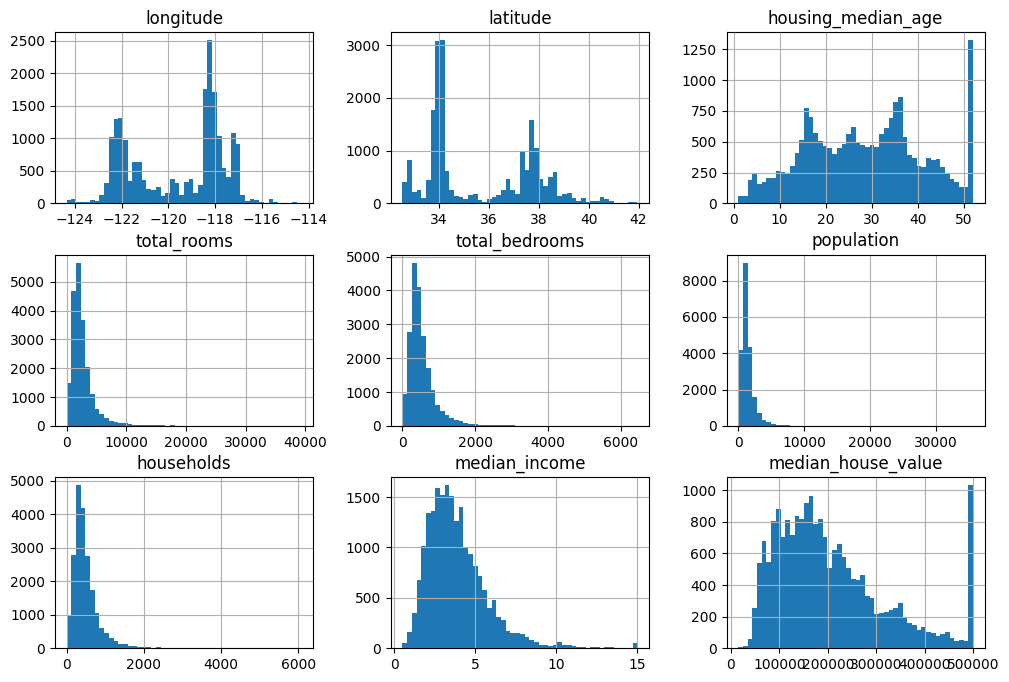

In [ ]:
housing_df.hist(bins=50, figsize=(12, 8))
plt.show()

* En primer lugar, el atributo o característica *median_income* no parece estar expresado en dólares estadounidenses (USD). Tras consultar con la documentación, los datos se han escalado y limitado a 15 (en realidad, \$150,000) para ingresos medios más altos, y a 0.5 (en realidad, 0,4999) para ingresos medios más bajos. Las cifras representan aproximadamente decenas de miles de dólares (por ejemplo, 3 significa aproximadamente \$30,000). Trabajar con características preprocesadas ​​es común en el aprendizaje automático. Es importante comprender cómo se calcularon los datos.

* *housing_median_age* y *median_house_value* también se limitaron. Esto es grave para nuestro objetivo. Los algoritmos de aprendizaje automático podrían aprender que los precios nunca superan ese límite.  Posibles estrategías: Recolectar nuevamente los datos o eliminar esos distritos dejando en claro los alcances del modelo.
* Las características tienen escalas muy diferentes.
* Muchos histogramas están sesgados a la derecha: se extienden mucho más a la derecha de la mediana que a la izquierda. ¿Valores extremos?.

**Correlaciones**

El análisis de correlación es crucial en la construcción de cualquier modelo. Es necesario comprender la distribución de los datos y cómo las variables independientes se correlacionan con la variable dependiente.

Para empezar a ver relaciones entre variables numéricas, trazar pares de gráficos de dispersión.

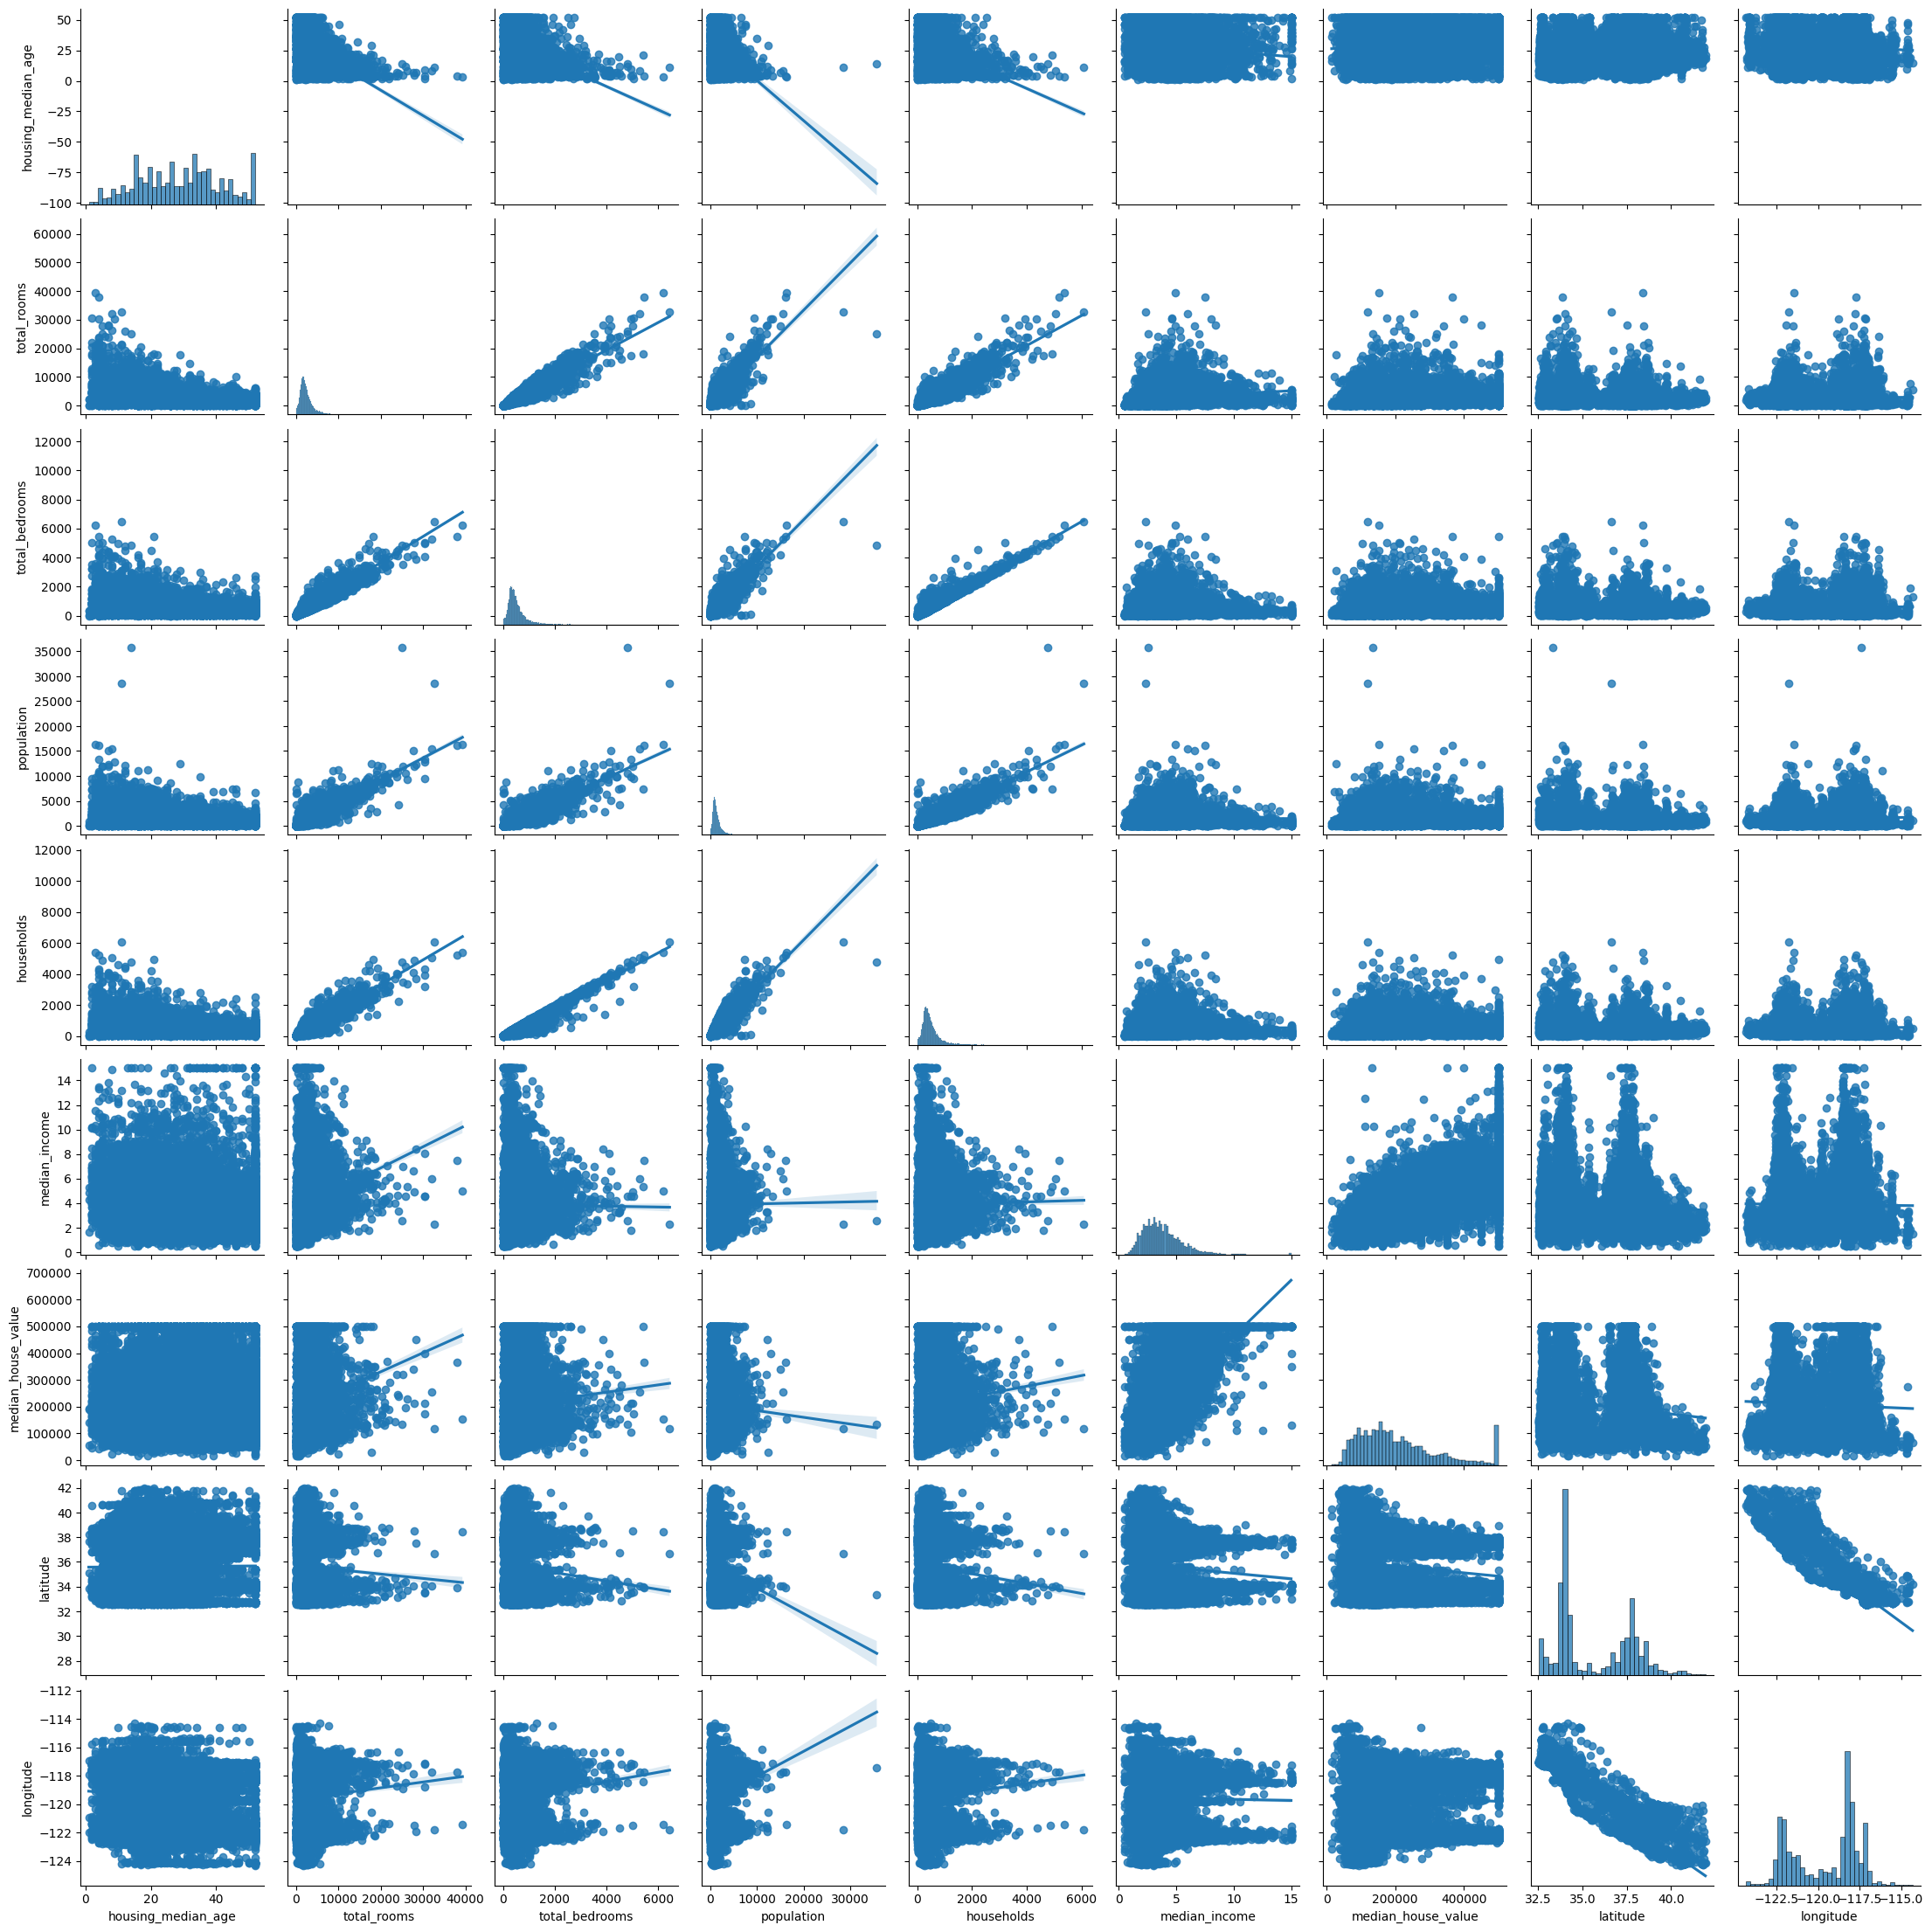

In [ ]:
sns.pairplot(data= housing_df[['housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'latitude', 'longitude']], kind="reg")

Se observa relaciones lineales:

* Entre *total_rooms, total_bedrooms, population y households* lo cual tiene sentido al medir totales basados en hogares/personas es distritos.
* Entre *median_income y median_house_value*.
* Entre *latitude y longitude*.



Text(0.5, 1.0, 'Correlación lineal entre Median income/Median House value')

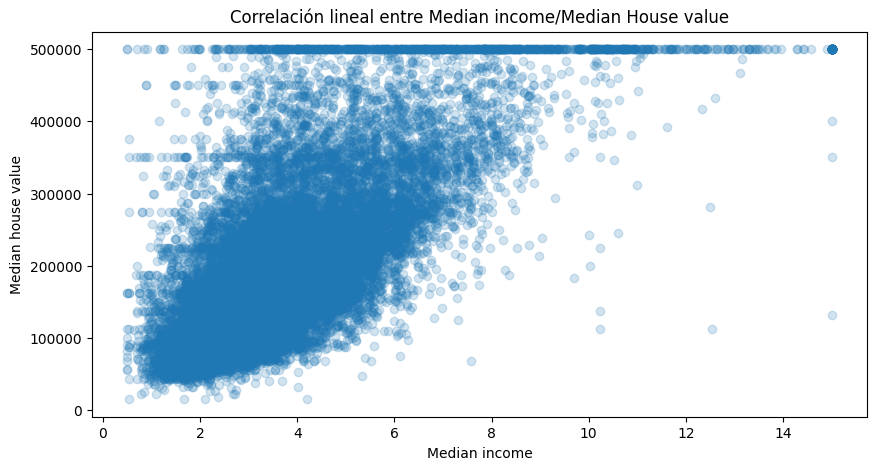

In [ ]:
# Correlación entre el median_income y la median_house_value
plt.figure(figsize=(10,5))
plt.scatter(housing_df["median_income"],housing_df["median_house_value"], alpha=0.2)
plt.xlabel('Median income')
plt.ylabel('Median house value')
plt.title('Correlación lineal entre Median income/Median House value')

**¿Cómo se relacionan las variables latitud y longitud con el precio mediano de vivienda en distrito?**

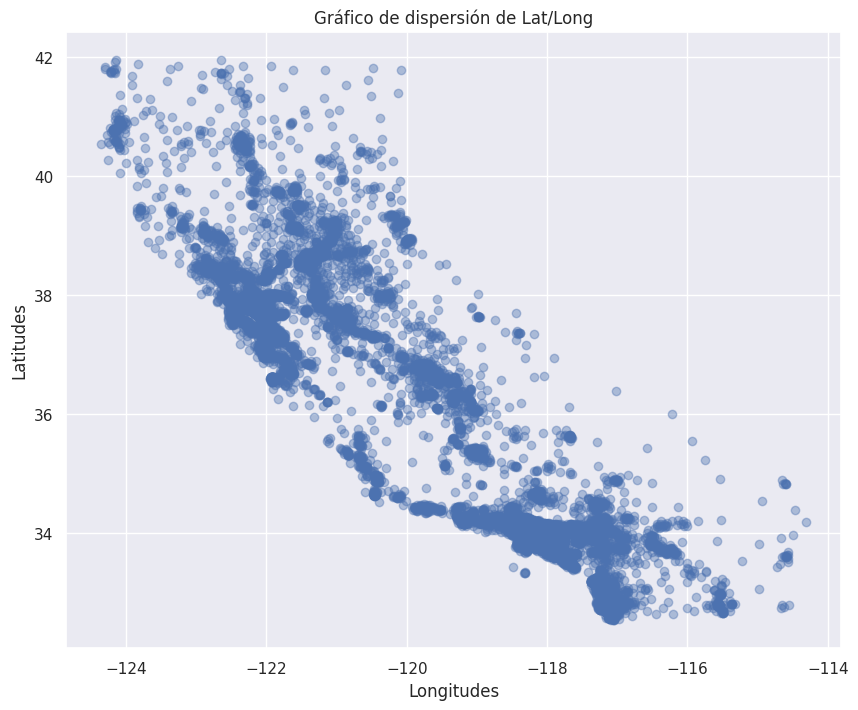

In [ ]:
sns.set()
plt.figure(figsize=(10,8))#Figure size
plt.scatter('longitude', 'latitude', data=housing_df, alpha=0.4) # ver alpha=0.2
plt.ylabel('Latitudes')
plt.xlabel('Longitudes')
plt.title('Gráfico de dispersión de Lat/Long')
plt.show()

Se puede ver claramente las áreas de alta densidad, como el Área de la Bahía y los alrededores de Los Ángeles y San Diego, además de una larga línea de áreas de alta densidad en el Valle Central (en particular, alrededor de Sacramento y Fresno).

<Figure size 1000x700 with 0 Axes>

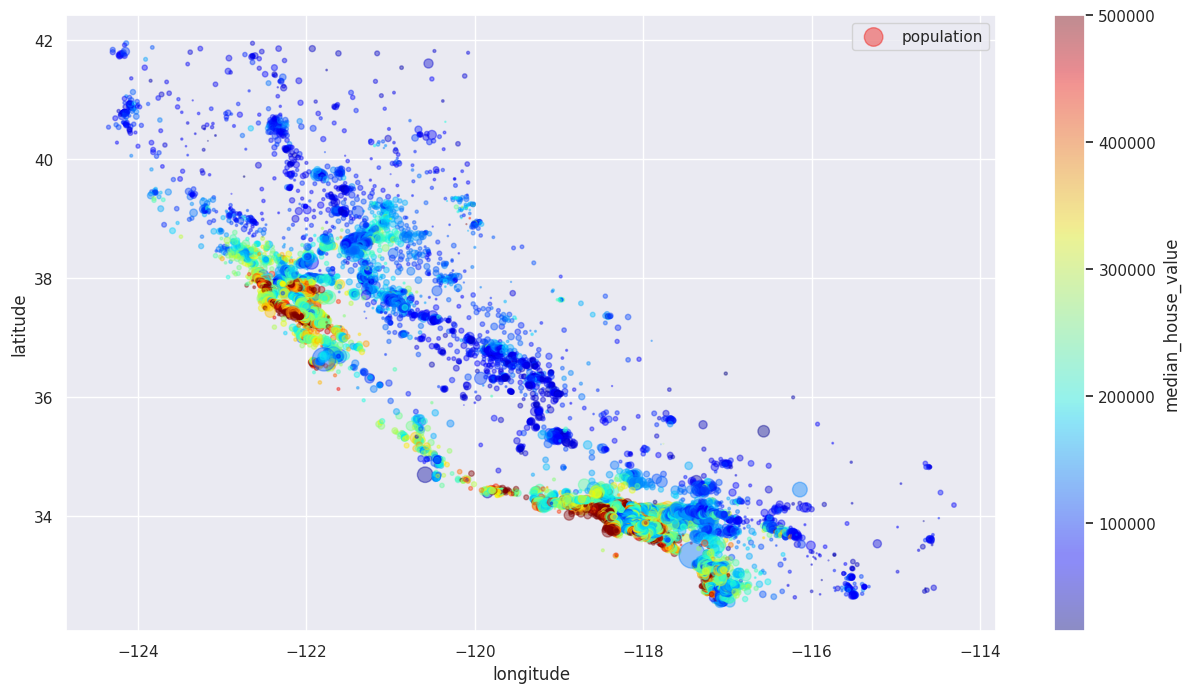

In [ ]:
plt.figure(figsize=(10,7))
housing_df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
        s=housing_df["population"]/100, label="population", figsize=(15,8),
        c="median_house_value", cmap=plt.get_cmap("jet"),colorbar=True,
    );
plt.legend();

En la gráfica, se observan los precios medianos de la vivienda. El radio de cada círculo representa la población del distrito (parámetro `s`) y el color representa el precio (parámetro `c`). Aquí se utiliza un mapa de colores predefinido (parámetro `cmap`) llamado jet, que va del azul (valores bajos) al rojo (precios altos). Se observa que los precios medianos de las viviendas están muy relacionados con la ubicación (por ejemplo, cerca del océano) y con la densidad de población, como probablemente ya se sabia.

Usando mapas

In [ ]:
pip install folium --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: folium
    Found existing installation: folium 0.19.7
    Uninstalling folium-0.19.7:
      Successfully uninstalled folium-0.19.7


In [ ]:
import patsy
import folium
from folium import plugins
from folium.plugins import HeatMap
california_map = folium.Map(location=[36.7783,-119.4179], zoom_start = 6, min_zoom=5)

df_map = housing_df[['latitude', 'longitude']]
data = [[row['latitude'],row['longitude']] for index, row in df_map.iterrows()]
_ = HeatMap(data, radius=10).add_to(california_map)

california_map

Calculamos el coeficiente de correlación estándar (también llamado r de Pearson) entre cada par de características mediante el método corr(). Para ello, seleccionamos las variables numéricas.

In [ ]:
numeric_df = housing_df.select_dtypes(include=np.number) # otra forma #housing_df.select_dtypes((int, float))
display(numeric_df) # Seleccionamos variables numéricas

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


In [ ]:
corr_matrix = numeric_df.corr() # Matriz de correlación

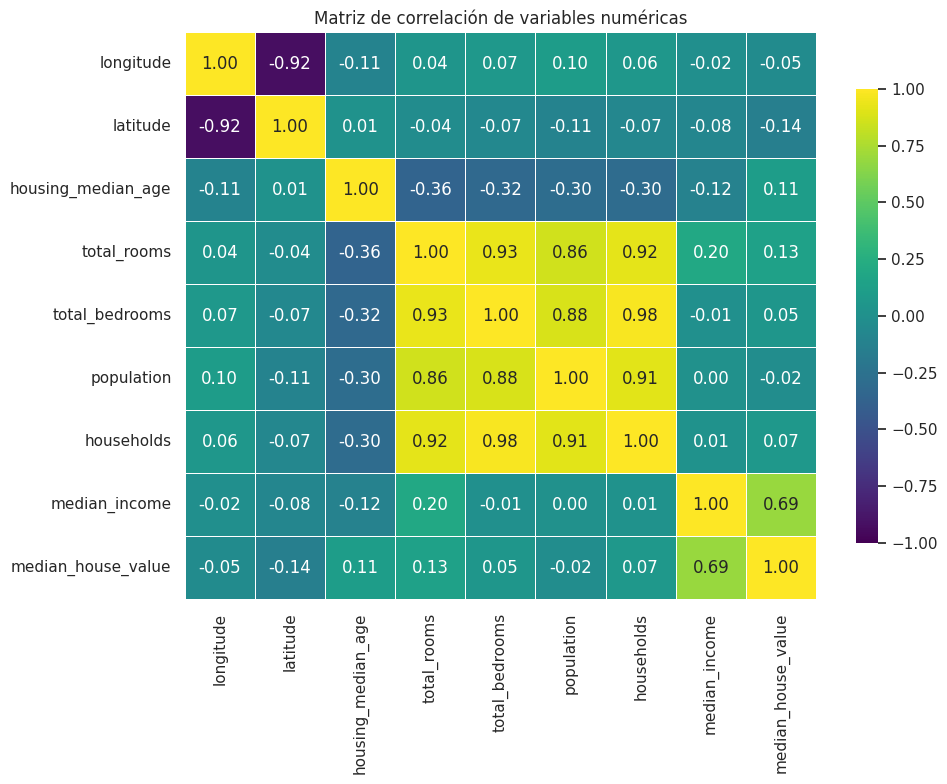

In [ ]:
#Crear el heatmap
plt.figure(figsize=(10, 8))  # Ajusta el tamaño del gráfico
sns.heatmap(corr_matrix,
            annot=True,              # Muestra los valores en cada celda
            fmt=".2f",               # Formato decimal
            cmap="viridis",         # Mapa de colores: rojo=negativo, azul=positivo
            vmin=-1, vmax=1,         # Rango fijo de correlación
            linewidths=0.5,          # Líneas divisorias finas
            cbar_kws={"shrink": .8}) # Ajusta la barra de colores

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160



Recordemos que el coeficiente de correlación oscila entre -1 y 1. Cuando se acerca a 1, significa que existe una fuerte correlación positiva; por ejemplo, *median_house_value* (valor mediano de la vivienda) tiende a aumentar cuando aumenta *median_income* (ingreso medio). Por otro lado, cuando el coeficiente se acerca a -1, significa que existe una fuerte correlación negativa; se puede observar una pequeña correlación negativa con la latitud (es decir, los precios tienden a bajar ligeramente al desplazarse hacia el norte). Por último, los coeficientes cercanos a 0 indican que no existe correlación lineal.

Recordatorio:

* total_rooms (habitaciones Totales): Número total de habitaciones dentro de una manzana.

* total_bedrooms(dormitorios Totales): Número total de dormitorios dentro de una manzana.

* population (población): Número total de personas que residen en una manzana.

* households (hogares): Número total de hogares, un grupo de personas que residen dentro de una unidad de vivienda, para una manzana.


Teniendo en cuenta *households* (hogares), existe una fuerte relación lineal entre total_rooms, total_bedrooms y population. Se puede observar una pequeña correlación negativa con housing_median_age, es decir que ante contrucciones nuevas o menor edad mediana de la vivienda mayor el númeto total de hogares en vivienda.

**En los modelos lineales múltiples, los predictores deben ser independientes, no debe de haber colinealidad entre ellos. La colinealidad ocurre cuando un predictor está linealmente relacionado con uno o varios de los otros predictores del modelo. Como consecuencia de la colinealidad, no se puede identificar de forma precisa el efecto individual que tiene cada predictor sobre la variable respuesta, lo que se traduce en un incremento de la varianza de los coeficientes de regresión estimados hasta el punto de que resulta imposible establecer su significancia estadística. Además, pequeños cambios en los datos, provocan grandes cambios en las estimaciones de los coeficientes. Es frecuente encontrar la llamada casi-colinealidad o multicolinealidad no perfecta (coeficiente de correlación que oscila entre -1 y 1 y).**

**Nuevas variables**




Por ejemplo, el número total de habitaciones en un distrito no es muy útil si no se conoce el número de hogares. Lo que realmente se busca es el número de habitaciones por hogar. De igual manera, el número total de dormitorios por sí solo no es muy útil: probablemente se quiera comparar con el número de habitaciones.Si crearemos nuevas variables que nos den esa información:

In [ ]:
housing_df1 = housing_df.copy()
housing_df1["rooms_per_house"] = housing_df1["total_rooms"] / housing_df1["households"]
housing_df1["bedrooms_ratio"] = housing_df1["total_bedrooms"] / housing_df1["total_rooms"]
housing_df1["people_per_house"] = housing_df1["population"] / housing_df1["households"]

¿Cómo se relacionan con la variable objetivo?

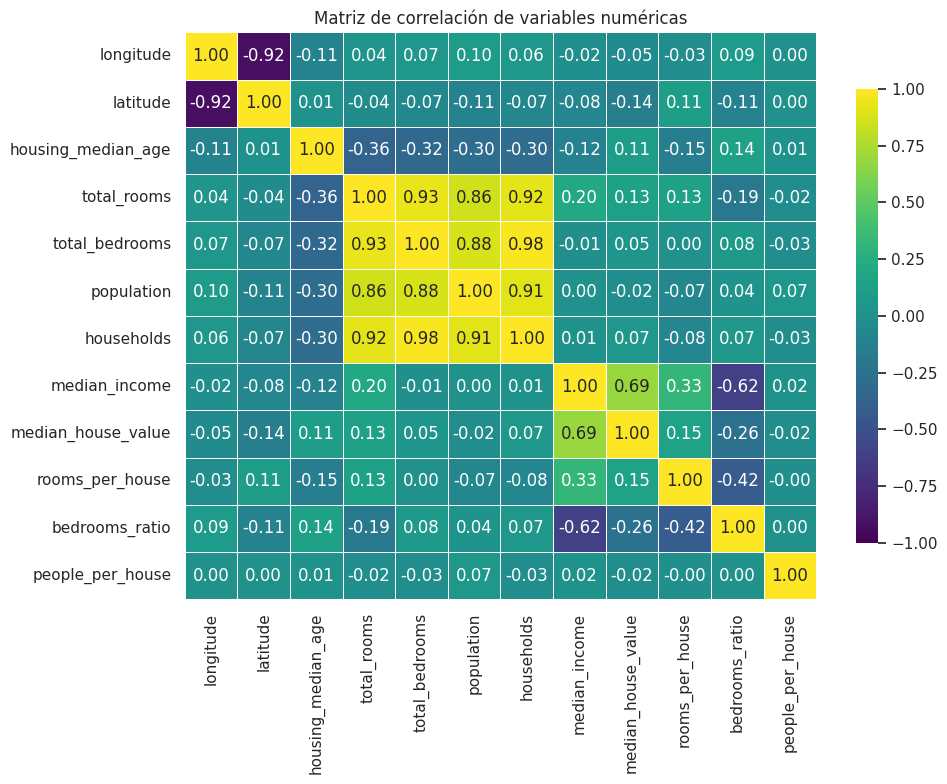

In [ ]:
corr_matrix = housing_df1.select_dtypes(include=np.number).corr()
#Crear el heatmap
plt.figure(figsize=(10, 8))  # Ajusta el tamaño del gráfico
sns.heatmap(corr_matrix,
            annot=True,              # Muestra los valores en cada celda
            fmt=".2f",               # Formato decimal
            cmap="viridis",         # Mapa de colores: rojo=negativo, azul=positivo
            vmin=-1, vmax=1,         # Rango fijo de correlación
            linewidths=0.5,          # Líneas divisorias finas
            cbar_kws={"shrink": .8}) # Ajusta la barra de colores

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

La nueva variable o característica *bedrooms_ratio* está mucho más correlacionada con el valor mediano de la vivienda que el número total de habitaciones o dormitorios. Al parecer, las casas con una menor proporción de dormitorios por habitaciones tenderían a ser más caras. La variable  *rooms_per_house* también es más informativa que *total_rooms* en un distrito; obviamente, cuanto más grandes son las casas, más caras son.
Por otro lado, se observa una correlación negativa entre  *bedrooms_ratio* y *median_income*



##### Identificando valores atípicos o outliers

Una manera rápida, es empezar por un análisis univariado, ver por variable y graficar su diagrama de bigotes o box plot.

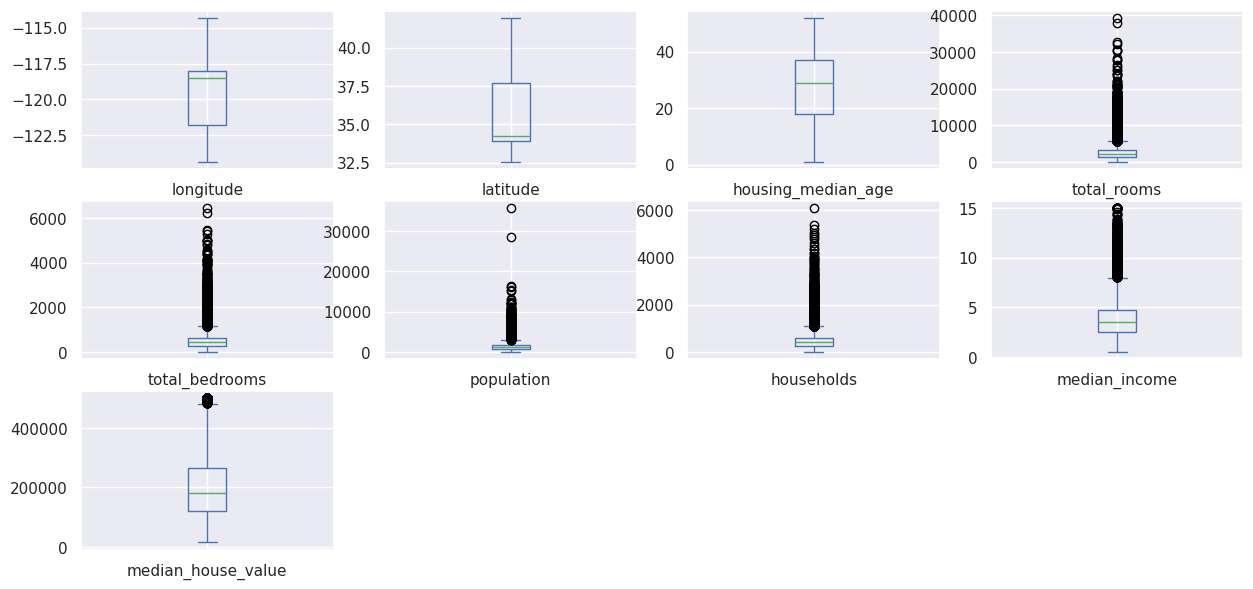

In [ ]:
housing_df.plot(kind='box', subplots=True,  layout=(3,4), figsize=(15,7))
plt.show()

Se observan valores extremos en la mayoría de las variables. Separar, eliminar, o controlar.

**Si el fin es predictivo, un modelo sin observaciones atípicas a altamente influyentes suele ser capaz de predecir mejor la mayoría de casos. Sin embargo, es muy importante prestar atención a estos valores ya que, de no tratarse de errores de medida, pueden ser los casos más interesantes o problematicos. El modo adecuado de proceder cuando se sospecha de algún posible valor atípico o influyente es calcular el modelo de regresión incluyendo y excluyendo dicho valor.**

##### Identificando datos Faltantes


Particularmente en el caso de la regresión, es importante asegurarnos que los datos no tengan valores faltantes porque la regresión no funcionará si los datos tienen valores faltantes.


In [ ]:
import missingno as msno # instalar e importar missingno

In [ ]:
def tabla_valores_faltantes(df):
  """
    Genera una tabla con el número y porcentaje de valores faltantes por columna en un DataFrame.

    Parámetros:
    df (pd.DataFrame): DataFrame de entrada.

    Retorna:
    pd.DataFrame: Tabla con columnas que tienen valores faltantes, indicando el número y porcentaje de valores faltantes.
  """
  faltantes_suma = df.isnull().sum() # total de valores faltantes
  faltantes_porc = 100 * (faltantes_suma / len(df)) # porcentaje de valores faltantes
  faltantes_df = pd.concat([faltantes_suma, faltantes_porc], axis=1) # tabla de resultados
  faltantes_df = faltantes_df.rename( # renombramos columnas
        columns = {0 : 'Valores faltantes', 1 : '% del total de valores'}, )

  faltantes_df = faltantes_df[ # ordenar
            faltantes_df.iloc[:,1] != 0].sort_values(
        '% del total de valores', ascending=False).round(1)
  print ("El Dataframe tiene " + str(df.shape[1]) + " columnas.\n"
            "Hay " + str(faltantes_df.shape[0]) +
              " Columnas que tienen valores faltantes.")

  return faltantes_df

In [ ]:
tabla_valores_faltantes(housing_df) # Llamar función para detectar valores faltantes

El Dataframe tiene 10 columnas.
Hay 1 Columnas que tienen valores faltantes.


,Valores faltantes,% del total de valores
total_bedrooms,207,1.0


**Visualización simple de nulidad**

El método bar() de la librería missingno permite identificar la cantidad de valores no nulos para cada una de las diferentes características o variables. Las barras muestran el número de valores que no faltan y su valor se indica al principio.

<Axes: >

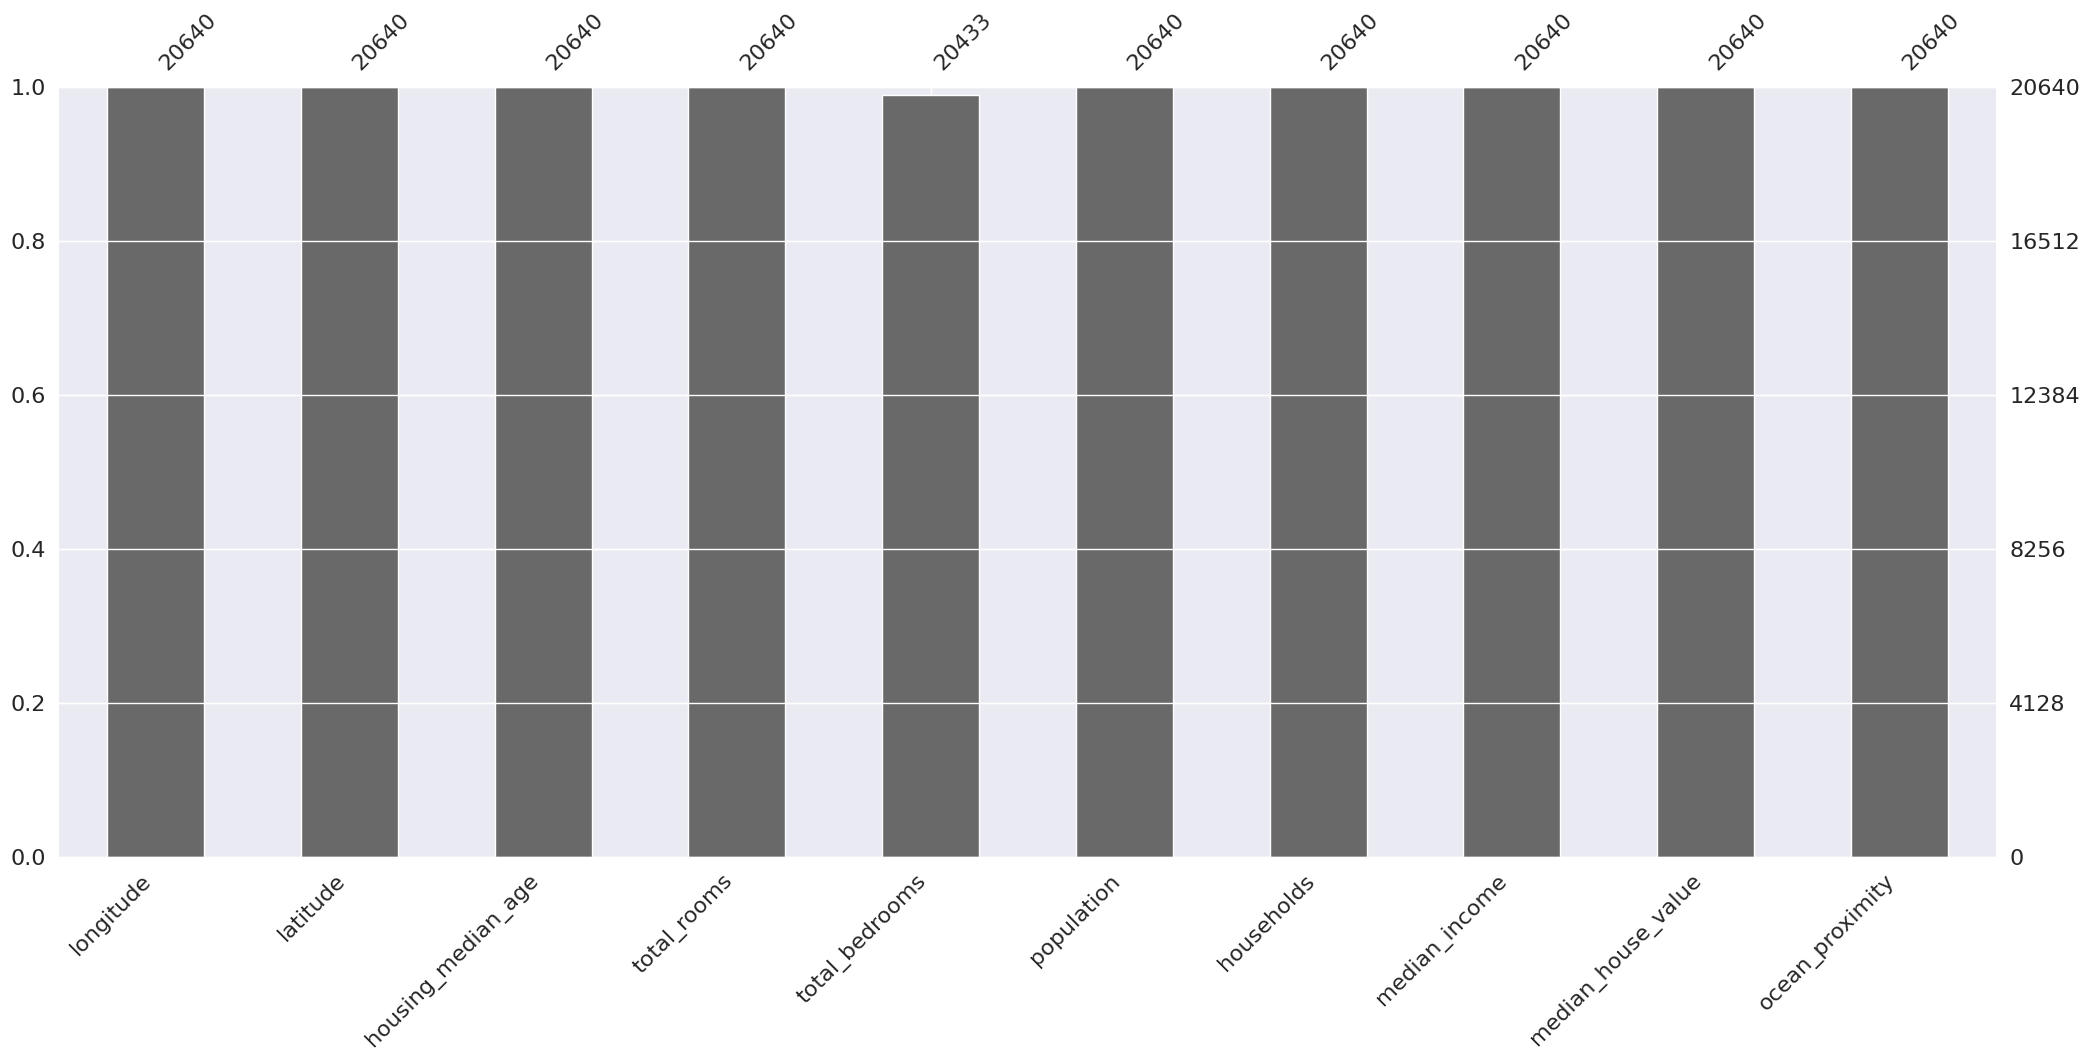

In [ ]:
msno.bar(housing_df) # Cantidad de valores faltantes por columna

Al ser tan bajo el número de datos faltantes para *total_bedrooms* se podría imputar por la mediana o eliminar. Es recomendable identificar que representan.

##### Manejo de texto y variables cualitativas o categóricas

En este conjunto de datos, solo hay una única variable: *ocean_proximity*.

In [ ]:
housing_df['ocean_proximity'].head(8)

,ocean_proximity
0,NEAR BAY
1,NEAR BAY
2,NEAR BAY
3,NEAR BAY
4,NEAR BAY
5,NEAR BAY
6,NEAR BAY
7,NEAR BAY


No es un texto arbitrario, hay un número limitado de valores posibles, cada uno de los cuales representa una categoría. Por lo tanto, esta característica es categórica. No es ordinal, podriamos codificar la variable por OneHotEncoder.

In [ ]:
housing_df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


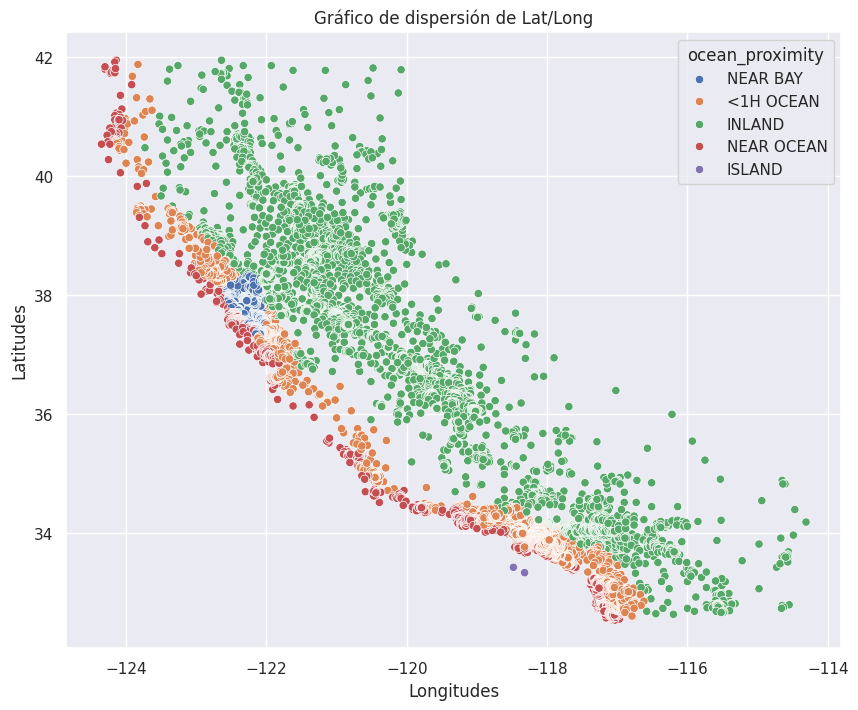

In [ ]:
sns.set()
plt.figure(figsize=(10,8))#Figure size
sns.scatterplot(data=housing_df, x='longitude',y='latitude', hue = 'ocean_proximity') # ver alpha=0.2
plt.ylabel('Latitudes')
plt.xlabel('Longitudes')
plt.title('Gráfico de dispersión de Lat/Long')
plt.show()

Esta ronda de exploración no tiene que ser exhaustiva; se trata de un proceso iterativo. Veamos que sucede con estas observaciones y transformaciones a realizar.

#### División de datos (datos de entrenamiento y prueba)

In [ ]:
# Características y etiquetas separadas

caracteristicas = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
etiqueta = 'median_house_value'

X = housing_df[caracteristicas].values # Entrada
Y = housing_df[etiqueta].values # Salida

# Imprimir algunos ejemplos
for n in range(0,4):
    print("\n distritos", str(n+1), "\n  Características:",list(X[n]), "\n  etiqueta:", Y[n])


 distritos 1 
  Características: [-122.23, 37.88, 41.0, 880.0, 129.0, 322.0, 126.0, 8.3252, 'NEAR BAY'] 
  etiqueta: 452600.0

 distritos 2 
  Características: [-122.22, 37.86, 21.0, 7099.0, 1106.0, 2401.0, 1138.0, 8.3014, 'NEAR BAY'] 
  etiqueta: 358500.0

 distritos 3 
  Características: [-122.24, 37.85, 52.0, 1467.0, 190.0, 496.0, 177.0, 7.2574, 'NEAR BAY'] 
  etiqueta: 352100.0

 distritos 4 
  Características: [-122.25, 37.85, 52.0, 1274.0, 235.0, 558.0, 219.0, 5.6431, 'NEAR BAY'] 
  etiqueta: 341300.0


Como ya vimos en el módulo anterior, Scikit-Learn proporciona varias funciones para dividir conjuntos de datos en múltiples subconjuntos de diversas maneras. La función más sencilla es **train_test_split()**. En primer lugar, el parámetro **random_state** permite establecer la semilla del generador aleatorio. En segundo lugar, se pueden pasar múltiples conjuntos de datos con el mismo número de filas tal que permite dividir según los mismos índices (esto es muy útil, por ejemplo, si se tiene un DataFrame independiente para las etiquetas).

In [ ]:
# Importar la biblioteca
from sklearn.model_selection import train_test_split

In [ ]:
# Dividir los datos en entrenamiento y prueba
x_train , x_test , y_train , y_test = train_test_split(housing_df[caracteristicas], housing_df[etiqueta]  , test_size= 0.3 , random_state=42)

In [ ]:
print("Datos de entrenamiento X{} Y{}\nDatos de prueba X{} Y{}".format(x_train.shape, y_train.shape, x_test.shape, y_test.shape))

Datos de entrenamiento X(14448, 9) Y(14448,)
Datos de prueba X(6192, 9) Y(6192,)


#### Preparación de los datos


Es conveniente escribir funciones y crear pipeline, serie de pasos o fases que guía las transformaciones de los datos, por varias buenas razones:

* Reproducir las transformaciones fácilmente en cualquier conjunto de datos (por ejemplo, la próxima vez que obtenga un nuevo conjunto de datos).

* Crear una biblioteca de funciones de transformación que se puede reutilizar en proyectos futuros.

* Usar las funciones en un sistema en vivo para transformar los nuevos datos antes de incorporarlos a los algoritmos.

* Probar  varias transformaciones y ver qué combinación funciona mejor.

##### Pipeline

Como se puede ver, hay muchos pasos de transformación de datos que deben ejecutarse en el orden correcto.

En scikit-learn, tanto **Pipeline** como **make_pipeline** se utilizan para crear una secuencia de transformaciones y estimadores que se pueden considerar como una sola unidad.

* [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): Esto requiere que se nombre explícitamente cada paso de la secuencia.

* [make_pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html): Esto asigna automáticamente nombres a cada paso según los nombres de clase de los estimadores.

Veamos un ejemplo simple

In [ ]:
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Definir la clase pipeline con pasos nombrados explícitamente
pipe = Pipeline([
    ('scaler', StandardScaler()), # Paso 1
    ('logisticregression', LogisticRegression()) # Paso 2
    ])


# Definir la clase make_pipeline
make_pipe = make_pipeline(
    StandardScaler(), # Paso 1
    LogisticRegression() # Paso 2
    )

# Para ver
print(make_pipe.get_params())
print(pipe.get_params())  # True
print(make_pipe.steps)
print(pipe.steps)

{'memory': None, 'steps': [('standardscaler', StandardScaler()), ('logisticregression', LogisticRegression())], 'transform_input': None, 'verbose': False, 'standardscaler': StandardScaler(), 'logisticregression': LogisticRegression(), 'standardscaler__copy': True, 'standardscaler__with_mean': True, 'standardscaler__with_std': True, 'logisticregression__C': 1.0, 'logisticregression__class_weight': None, 'logisticregression__dual': False, 'logisticregression__fit_intercept': True, 'logisticregression__intercept_scaling': 1, 'logisticregression__l1_ratio': None, 'logisticregression__max_iter': 100, 'logisticregression__multi_class': 'deprecated', 'logisticregression__n_jobs': None, 'logisticregression__penalty': 'l2', 'logisticregression__random_state': None, 'logisticregression__solver': 'lbfgs', 'logisticregression__tol': 0.0001, 'logisticregression__verbose': 0, 'logisticregression__warm_start': False}
{'memory': None, 'steps': [('scaler', StandardScaler()), ('logisticregression', Logi

Retomando a la transformación de los datos de distritos, a demás de usar las clases vistas agregamos la clase **ColumnTransformer** que aplica transformadores a las columnas de una matriz o un DataFrame de pandas. Para más información, [documentación oficial](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html).

Pasos a realizar:
* Imputar valores faltantes por valor de la mediana o moda según tipo de variable.
* Escalar variables numéricas
* Codificar variables categóricas


In [ ]:
from sklearn.pipeline import make_pipeline # Para pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Variables numéricas
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
"total_bedrooms", "population", "households", "median_income"]

# Pipeline para variables numéricas
num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"), # Imputar valores faltantes
    StandardScaler() # Escalar por Z-score
    )

# Variables categóricas
cat_attribs = ["ocean_proximity"]
# Pipeline para variables categóricas
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"), # Imputar valores faltantes
    OneHotEncoder(handle_unknown="ignore", drop="first") # Codificar por onehotencoder
    )

# Transformar cada variable a utilizar con la clase ColumnTransformer
preprocessing = ColumnTransformer([
("num", num_pipeline, num_attribs),
("cat", cat_pipeline, cat_attribs),
])

# Visualizar los pasos o transformaciones que requieren
display(preprocessing)

# Seleccionar datos de entrenamiento y prueba para transformar
x_train_p , x_test_p , y_train_p, y_test_p = x_train.copy() , x_test.copy() , y_train.copy() , y_test.copy()
display(x_train_p.head(2))
display(y_train_p[:2])

# Entrenar sobre datos de entrenamiento. El objeto preprocessing esta entrenado
preprocessing = preprocessing.fit(x_train_p)

# Transformar los datos de entrenamiento
housing_train = preprocessing.transform(x_train_p)
x_train_pp = pd.DataFrame(
housing_train, columns=preprocessing.get_feature_names_out(),
index=x_train_p.index)


# Transformar los datos de prueba
housing_test = preprocessing.transform(x_test_p)
x_test_pp = pd.DataFrame(
housing_test, columns=preprocessing.get_feature_names_out(),
index=x_test_p.index)

print("Por pipeline y teniendo en cuenta los datos de entrenamiento (valores faltantes imputados)")
print(x_test_pp.shape)
display(x_test_pp.head(2))



ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['longitude', 'latitude', 'housing_median_age',
                                  'total_rooms', 'total_bedrooms', 'population',
                                  'households', 'median_income']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['ocean_proximity'])])

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
7061,-118.02,33.93,35.0,2400.0,398.0,1218.0,408.0,4.1312,<1H OCEAN
14689,-117.09,32.79,20.0,2183.0,534.0,999.0,496.0,2.8631,NEAR OCEAN


,median_house_value
7061,193800.0
14689,169700.0


Por pipeline y teniendo en cuenta los datos de entrenamiento (valores faltantes imputados)
(6192, 12)


,num__longitude,num__latitude,num__housing_median_age,num__total_rooms,num__total_bedrooms,num__population,num__households,num__median_income,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN
20046,0.286641,0.191664,-0.283463,-0.527023,-0.244962,-0.03151,-0.371710,-1.152689,1.0,0.0,0.0,0.0
3024,0.061963,-0.239115,0.112947,0.137801,-0.244962,0.12022,0.216975,-0.706406,1.0,0.0,0.0,0.0


**Observación**
* Con   *OneHotEncoder(handle_unknown="ignore", drop="first")*  si una variable categórica tiene k categorías, se generan solo k-1 columnas. Esto evita multicolinealidad en la regresión lineal mútliple. La categoría que se elimina se convierte en la **categoría de referencia** contra la cual se interpretan los coeficientes, esto lo veremos cuando ajustemos los modelos.

En el pipeline anterior no se generan nuevas variables. Para las transformaciones que no requieren entrenamiento, se puede escribir una función que tome un array de NumPy como entrada y genere el array transformado como salida. Tener en cuenta la clase [FunctionTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.FunctionTransformer.html)

In [ ]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import make_column_selector

def column_ratio(X):
  return X[:, [0]] / X[:, [1]]

def ratio_nombre(function_transformer, feature_names_in):
  return ["ratio"] # nombres de funciones fuera

def ratio_pipeline():
  return make_pipeline(
  SimpleImputer(strategy="median"), # Imputar valor faltante
  FunctionTransformer(column_ratio,
                      feature_names_out=ratio_nombre
                      ), # Aplicar función para generar nuevas variables
  StandardScaler() # Escalar por z-score
)


# Para las variables no detalladas
default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
    )


# Para transformaciones que requieren entrenamiento
# x_train_m["rooms_per_house"] = x_train_m["total_rooms"] / x_train_m["households"]
# x_train_m["bedrooms_ratio"] = x_train_m["total_bedrooms"] / x_train_m["total_rooms"]
# x_train_m["people_per_house"] = x_train_m["population"] / x_train_m["households"]
preprocessing = ColumnTransformer([
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)) #cat_attribs
],
remainder=default_num_pipeline)

display(preprocessing) # Objeto transformador

# Entrenar sobre datos de entrenamiento. El objeto preprocessing esta entrenado
preprocessing = preprocessing.fit(x_train_p)

# Transformar los datos de entrenamiento
housing_train = preprocessing.transform(x_train_p)
x_train_pp = pd.DataFrame(
housing_train, columns=preprocessing.get_feature_names_out(),
index=x_train_p.index)

# Transformar los datos de prueba
housing_test = preprocessing.transform(x_test_p)
x_test_pp = pd.DataFrame(
housing_test, columns=preprocessing.get_feature_names_out(),
index=x_test_p.index)

print("Por pipeline y teniendo en cuenta los datos de entrenamiento (valores faltantes imputados)")
print(x_test_pp.shape)
display(x_test_pp.head(2))



ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                             SimpleImputer(strategy='median')),
                                            ('standardscaler',
                                             StandardScaler())]),
                  transformers=[('rooms_per_house',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('functiontransformer',
                                                  FunctionTransformer(feature_names_out=<function ratio_nombre at 0x7d43679b1a80>,
                                                                      func=<function col...
                                                  FunctionTransformer(feature_names_out=<function ratio_nombre at 0x7d43679b1a80>,
                                                                      func=<function column_ratio at 0x7d43679b1800>)),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['population', 'households']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7d436762add0>)])

Por pipeline y teniendo en cuenta los datos de entrenamiento (valores faltantes imputados)
(6192, 11)


,rooms_per_house__ratio,bedrooms__ratio,people_per_house__ratio,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__longitude,remainder__latitude,remainder__housing_median_age,remainder__median_income
20046,-0.507818,1.324907,0.061278,1.0,0.0,0.0,0.0,0.286641,0.191664,-0.283463,-1.152689
3024,-0.162520,-1.106447,-0.035516,1.0,0.0,0.0,0.0,0.061963,-0.239115,0.112947,-0.706406


Luego de preprocesar los datos, vamos a crear un modelo de regresión lineal por Ordinary Least Squares (OLS), el método empleado con más frecuencia.





####  Regresión lineal por mínimos cuadrados ordinarios (Ordinary Least Squares)

 El mínimos cuadrados ordinarios (OLS), identifica como mejor modelo la recta (o plano si es regresión múltiple). Ajusta un modelo lineal con coeficientes $w = (w_1, …, w_p)$ para minimizar la suma de cuadrados de las diferencias entre los objetivos observados en el conjunto de datos y los objetivos predichos por la aproximación lineal.

**Estas diferencias se las identifican como residuos o errores**


Dos de las implementaciones de modelos de regresión lineal más utilizadas en Python son: **scikit-learn** y **statsmodels**.

Empecemos con `scikit-learn` y
[sklearn.linear_model.LinearRegression()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)


#### Regresión lineal simple: para introducirnos

Crear un primer modelo donde la variable de entrada sea **median_income** (X) y variable de respuesta **median_house_value** (Y).

**Consideraciones**
*  *median_income* presenta relación lineal con *median_house_value*.
* Las variables exploradas presentan valores atípicos.
* *median_house_value* está limitada a 500,001. Los algoritmos de aprendizaje automático podrían aprender que los precios nunca superan ese límite. Aún no se eliminaron valores.

In [ ]:
from sklearn import linear_model # importar librerías
from sklearn.metrics import  root_mean_squared_error
# Crear modelo - configuración
ols_reg = linear_model.LinearRegression()
display(ols_reg) # Modelo

# Entrenar
ols_reg.fit(x_train[["median_income"]], y_train)

# Predecir
train_pred_ols = ols_reg.predict(x_train[["median_income"]])
test_pred_ols = ols_reg.predict(x_test[["median_income"]])

# Calcular el coeficiente de determinación R^2 de entrenamiento. Bonda de ajuste
print("R2 en datos de entrenamiento:",ols_reg.score(x_train[["median_income"]], y_train))

# Informar el término independiente o sesgo (bias)
print("bias:",ols_reg.intercept_)

# Informar los pesos aprendidos w
#ols_reg.coef_[0]
display(pd.DataFrame(ols_reg.coef_[0],["median_income"],  columns=["Coeficient"]))

# Calcular Métrica para evaluar
rmse = root_mean_squared_error(y_test, test_pred_ols)
print(" Raíz del MSE de la regresión lineal:", rmse)



LinearRegression()

R2 en datos de entrenamiento: 0.4736591808481234
bias: 44794.96555604314


,Coeficient
median_income,41819.326976


 Raíz del MSE de la regresión lineal: 83174.39430526982


y_test_1 = y_train.values.reshape(-1, 1)
y_test_1[:5]

y_pred_1= train_pred_ols.reshape(-1, 1)
y_pred_1[:5]

In [ ]:
y_test_1 = y_train.values.reshape(-1, 1)
print(y_test_1[:5])

y_pred_1= train_pred_ols.reshape(-1, 1)
print(y_pred_1[:5])

[[193800.]
 [169700.]
 [259800.]
 [136100.]
 [500001.]]
[[217558.96915923]
 [164527.88062098]
 [220544.86910531]
 [174827.98085517]
 [183083.11600023]]


In [ ]:
errors = y_test_1 - y_pred_1

# Error Cuadrático Medio (MSE)
mse_manual = np.mean(errors**2)
print("mse_manual:",mse_manual)


# Raíz del Error Cuadrático Medio (RMSE)
rmse_manual = np.sqrt(mse_manual)
print("rmse_manual:",rmse_manual)


# Error Absoluto Medio (MAE)
mae_manual = np.mean(np.abs(errors))
print("mae_manual:",mae_manual)


# R² (Coeficiente de determinación)
ss_res = np.sum((y_test_1 - y_pred_1)**2)
ss_tot = np.sum((y_test_1 - np.mean(y_test_1))**2)
r2_manual = 1 - ss_res / ss_tot
print("r2_manual:",r2_manual)

print("\n Para 5 elementos")
print("y_real: ",y_test_1[:5])
print("y_pred: ",y_pred_1[:5])
print("Residuos:", errors[:5])
print("mse_manual para 5:",np.mean(errors[:5]**2))
print("rmse_manual para 5:",np.sqrt(np.mean(errors[:5]**2)))
print("mae_manual para 5:", np.mean(np.abs(errors[:5])))
ss_res = np.sum((y_test_1[:5] - y_pred_1[:5])**2)
ss_tot = np.sum((y_test_1[:5] - np.mean(y_test_1[:5]))**2)
r2_manual = 1 - ss_res / ss_tot
print("r2_manual para 5:",r2_manual)

mse_manual: 7051366781.970439
rmse_manual: 83972.41679248275
mae_manual: 62703.31728532416
r2_manual: 0.4736591808481234

 Para 5 elementos
y_real:  [[193800.]
 [169700.]
 [259800.]
 [136100.]
 [500001.]]
y_pred:  [[217558.96915923]
 [164527.88062098]
 [220544.86910531]
 [174827.98085517]
 [183083.11600023]]
Residuos: [[-23758.96915923]
 [  5172.11937902]
 [ 39255.13089469]
 [-38727.98085517]
 [316917.88399977]]
mse_manual para 5: 20813801287.190228
rmse_manual para 5: 144269.8904386852
mae_manual para 5: 84766.41685757463
r2_manual para 5: -0.22206096922019625


In [ ]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

# Supongamos que ya tenés y_test (valores reales) y y_pred (predicciones)
mse = mean_squared_error(y_test, test_pred_ols)
rmse = root_mean_squared_error(y_test, test_pred_ols)  # raíz del MSE
mae = mean_absolute_error(y_test, test_pred_ols)
r2 = r2_score(y_test, test_pred_ols)
r2_ajus = 1 - ((1-r2)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1))
#

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")
print(f"R²ajustado: {r2_ajus:.2f}")

MSE: 6917979868.05
RMSE: 83174.39
MAE: 62315.59
R²: 0.47
R²ajustado: 0.47


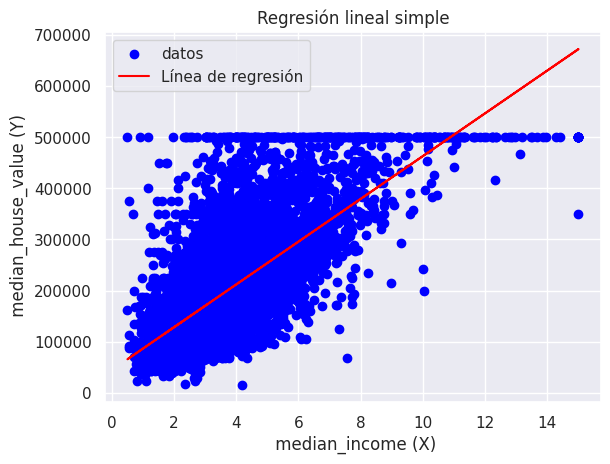

In [ ]:
plt.scatter(x_test['median_income'], y_test, color='blue', label='datos')
plt.plot(x_test['median_income'], test_pred_ols, color='red', label='Línea de regresión')
plt.xlabel(' median_income (X)')
plt.ylabel( ' median_house_value (Y)')
plt.title('Regresión lineal simple')
plt.legend()
plt.show()

* `fit(x_train, y_train)`: Ajusta el modelo de regresión lineal utilizando los datos de entrenamiento (`x_train` e `y_train`). Este método encuentra los coeficientes óptimos para la ecuación de regresión lineal basándose en los datos de entrenamiento.

* `score(x_train, y_train)`: Calcula el coeficiente de determinación $R^2$ del modelo utilizando los datos de entrenamiento (`x_train` e `y_train`). El coeficiente de determinación $R^2$ indica la proporción de la varianza explicada por el modelo y proporciona una medida de qué tan bien se ajusta el modelo a los datos de entrenamiento.

  * Bonda de ajuste del modelo: Una vez ajustado el modelo, es necesario verificar su utilidad ya que, aun siendo la línea o plano que mejor se ajusta a las observaciones de entre todas las posibles, puede tener un gran error.
  * En los modelos de regresión lineal simple el valor de R2
 se corresponde con el cuadrado del coeficiente de correlación de Pearson (r) entre X e y, no siendo así en regresión múltiple.

* `intercept_`: Devuelve el término de intercepción (también conocido como el coeficiente $b_0$ o el valor del eje $y$ cuando $x$ es 0) del modelo de regresión lineal. Este valor representa el punto en el que la línea de regresión intersecta el eje $y$.
* `coef_`: Devuelve los coeficientes de regresión ($w_1, w_2, ..., w_p$) del modelo de regresión lineal. Estos coeficientes representan las pendientes de las variables predictoras ($x_1, x_2, ..., x_p$) en la ecuación de regresión lineal.

📝 Ejercicio

En base a la información del modelo:
* Escribir la ecuación de la recta que genera el modelo.
* Predecir el valor del precio mediano de vivienda para el distrito con `median_income=2` (equivalente a 20k). Interpretar.


In [ ]:
# Respuesta



**Haz doble click para ver la respuesta**
<!--
# Manualmente
X = 2
# Ecuación de la recta
Y =  44794.9655 + 41819.3269*X

# Imprimir prediccion para X=2
print(Y)

# Otra forma - tener en cuenta la estructura de datos en el que se entreno el modelo.

X = pd.DataFrame([X])
print(ols_reg.predict(X))
# 128433.61929999999

# Si el ingreso mediano de un distrito es de 20000 (2 unidades) el precio mediano de la vivienda es de 128,433.619299
-->




Usando Statsmodels (enfoque estadístico) [statsmodels.regression.linear_model.OLS]( https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html#statsmodels.regression.linear_model.OLS)

In [ ]:
import statsmodels.api as sm

# Datos
X = x_train[["median_income"]].copy()
X = sm.add_constant(X)  # Agrega el intercepto (bias)
y = y_train

# Ajustar modelo
sm_ols_reg = sm.OLS(y, X).fit()

# Predecir
y_pred_ols = sm_ols_reg.predict(sm.add_constant(x_test[["median_income"]])  )

# Calcular Métrica para evaluar
rmse = root_mean_squared_error(y_test, y_pred_ols)
print(" Raíz del MSE de la regresión lineal:", rmse)

# Ver resumen
print(sm_ols_reg.summary()) #  tabla resumen con resultados estadísticos

 Raíz del MSE de la regresión lineal: 83174.39430526982
                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.474
Model:                            OLS   Adj. R-squared:                  0.474
Method:                 Least Squares   F-statistic:                 1.300e+04
Date:                Thu, 19 Jun 2025   Prob (F-statistic):               0.00
Time:                        13:54:34   Log-Likelihood:            -1.8432e+05
No. Observations:               14448   AIC:                         3.686e+05
Df Residuals:                   14446   BIC:                         3.687e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

Para más información [documentación de Statsmodels](
https://www.statsmodels.org/stable/regression.html).


Te recomendamos leer ["Introduction to Statistical Learning (ISLR)"](https://hastie.su.domains/ISLP/ISLP_website.pdf.download.html)
Los capítulos 3 y 6 explican regresión, test de hipótesis, p-valores y más.


#### Interpretación

Tomando como referencia el resumen de OLS por statsmodels y los resultados brindados por scikit-learn, aquí algunas interpretaciones:

**Evaluación del Ajuste del modelo**

En base a los datos entrenamiento el R² es 0.47. El modelo explica el 47,4% de la variabilidad en *median_house_value*. Aún queda más del 50% sin explicar.

Si observas, aquí no estamos evaluando los datos de prueba, estamos explorando que tan bien se ajusta al modelo, que junto a otros estadísticos nos ayudarán a seguir ajustando el modelo en tanto y cuanto vayamos validando supuestos claves para garantizar el aprendizaje e inferencia del modelo. Por lo pronto analizar aquí la métrica Raíz del error cuadrático sobre los datos de prueba no tendría sentido.

  * Con la librería statsmodels también tenemos información sobre, F-statistic, AIC y BIC.
    * Estadístico F y Prob(Estadístico F): El estadístico F se utiliza para comprobar la significancia global del modelo. La hipótesis nula establece que todos los coeficientes (excepto el intercepto) son cero, lo que significa que el modelo no explica ninguna varianza en la variable dependiente. Un valor p bajo (normalmente inferior a 0,05) indica que el modelo es estadísticamente significativo, lo que significa que al menos una de las variables independientes tiene un efecto significativo sobre la variable dependiente. Si el test  F  resulta significativo, implica que el modelo es útil, pero no que sea el mejor. Podría ocurrir que alguno de sus predictores no fuese necesario. Para el ejemplo el modelo tiene poder explicativo.

    * Adj. R-squared: Como solo hay una variable, es igual a R². Si se agregaran más variables, este nos diría si mejora o empeora el modelo. Está métrica la detallaremos más adelante.


**Coeficientes del modelo**
* const (intercepto) es	44,790, esto quiere decir que el valor esperado del precio mediano de viviendas en distritos es \$44,790
cuando todos los predictores son cero. Se podría interpretar como el precio base.


* El coeficiente de *median_income* es 41,820, esto representa que por cada unidad adicional (1 unidad es 10k) en *median_income*, se espera que el precio mediano de la vivienda aumente, en promedio, $41,820 manteniéndose constantes el resto de variables.

  **La magnitud de cada coeficiente de regresión depende de las unidades en las que se mida la variable predictora a la que corresponde, por lo que su magnitud no está asociada con la importancia de cada predictor.**

* Significancia de los predictores. Con la librería statsmodels también nos informamos por cada variable, t-value, P>|t| e intervalo de confinanza.
  * t-value, P>|t|:
Las estadísticas t se calculan dividiendo el coeficiente entre su error estándar. Estos valores se utilizan para comprobar la hipótesis nula de que el coeficiente es cero (es decir, que la variable independiente no afecta a la variable dependiente).
Los valores p asociados a estas estadísticas t indican la probabilidad de observar el coeficiente estimado (o un valor más extremo) si la hipótesis nula fuera cierta. Un valor p inferior a un cierto nivel de significancia (normalmente 0,05) sugiere que el coeficiente es estadísticamente significativo, lo que significa que la variable independiente afecta significativamente a la variable dependiente. Para el ejemplo ambos coeficientes son altamente significativos (p < 0.001).

  * Intervalos de confianza: Los intervalos de confianza indican un rango dentro del cual probablemente se encuentre el coeficiente real, con un cierto nivel de confianza (generalmente del 95%).
  Si un intervalo de confianza incluye cero, significa que existe la posibilidad de que la variable no afecte realmente el resultado.
  Si el cero no está en el intervalo, es más probable que la variable realmente afecte el resultado.

**Para que los cálculos descritos anteriormente sean válidos, se tiene que asumir que los residuos son independientes y que se distribuyen de forma normal con media 0 y varianza constante $\sigma^2$**

**Diagnóstico**

La librería statsmodels nos brinda información sobre los residuos del modelo, errores. Esto es importante para validar las condiciones que  deben cumplirse en los datos para aplicar regresión lineal. En la práctica no siempre se cumplen los supuestos, pero es importantes tenerlos en cuenta en la evaluación del modelo.
Del resumen se obtienen información de pruebas de normalidad (omnibus, Jarque-Bera), simetría (Skew, Kurtosis), autocorrelación (Durbin-Watson), y multicolinealidad (Cond. No). Para el ejemplo, los residuos no cumplen la normalidad, lo que podría afectar la validez de los intervalos de confianza y tests.


**Los supuestos para aplicar regresión lineal lo estaremos analizando más adelante.**


#### Regresión lineal multiple: Variables transformadas

Vamos a tener en cuenta la clase **columntransformer** y **make_pipeline** , para tranformar los datos y entrenar el modelo de regresión. Vamos a retomar lo ya visto.

**Preprocesamiento**
* Imputar valores faltantes por valor de la mediana o moda según tipo de variable.
* Crear nuevas variables ratios.
* Escalar variables numéricas por z-score.
* Codificar variables categóricas por onehotencoder.

**Consideraciones**
* En base al EDA, hay variables correlaciondas.
* Las variables exploradas presentan valores atípicos.
* *median_house_value* está limitada a 500,001. Los algoritmos de aprendizaje automático podrían aprender que los precios nunca superan ese límite. Aún no se eliminaron valores. No se transforma la variable respuesta.




In [ ]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline # Para pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn import linear_model # importar librerías
from sklearn.metrics import  root_mean_squared_error

###########################
# Funciones claves
###########################


def column_ratio(X):
  return X[:, [0]] / X[:, [1]]

def ratio_nombre(function_transformer, feature_names_in):
  return ["ratio"] # nombres de funciones fuera

def ratio_pipeline():
  return make_pipeline(
  SimpleImputer(strategy="median"), # Imputar valor faltante
  FunctionTransformer(column_ratio,
                      feature_names_out=ratio_nombre
                      ), # Aplicar función para generar nuevas variables
  StandardScaler() # Escalar por z-score
)

###########################
# Preprocesamiento
###########################
# Variables categóricas
cat_attribs = ["ocean_proximity"]
# Pipeline para variables categóricas
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"), # Imputar valores faltantes
    OneHotEncoder(handle_unknown="ignore", drop="first"), # Codificar por onehotencoder

    )


# Para las variables no detalladas
default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
    )

# Transformador
preprocessing = ColumnTransformer([
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)) #cat_attribs
],
remainder=default_num_pipeline)


# Crear make_pipeline
lin_reg = make_pipeline(
    preprocessing, # Preprocesar datos
    linear_model.LinearRegression() # Crear modelo
    )

# Transformar y entrenar modelo
display(lin_reg.fit(x_train, y_train))

# Transformar y predecir
train_pred = lin_reg.predict(x_train)
pred = lin_reg.predict(x_test)

# Acceder al modelo dentro del pipeline
ols_reg = lin_reg.named_steps['linearregression']

# Calcular el coeficiente de determinación R^2 de entrenamiento
print("R2 en datos de entrenamiento:",lin_reg.score(x_train, train_pred))

# Informar el término independiente o sesgo (bias)
print("bias:",ols_reg.intercept_)

# Informar los pesos aprendidos w
#ols_reg.coef_[0]

# Acceder al transformador
preprocessing = lin_reg.named_steps['columntransformer']
display(pd.DataFrame(ols_reg.coef_,preprocessing.get_feature_names_out(),  columns=["Coeficient"]))


# Calcular Métrica para evaluar
rmse = root_mean_squared_error(y_test, pred)
print(" Raíz del MSE de la regresión lineal:", rmse)



Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('rooms_per_house',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_nomb...
                                                                                       func=<function column_ratio at 0x7d43652ff560>)),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['population', 'households']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7d4369ee8150>)])),
                ('linearregression', LinearRegression())])

R2 en datos de entrenamiento: 1.0
bias: 217249.72845962807


,Coeficient
rooms_per_house__ratio,8404.660845
bedrooms__ratio,19744.999616
people_per_house__ratio,-4084.709982
cat__ocean_proximity_INLAND,-36407.280888
cat__ocean_proximity_ISLAND,139420.409736
cat__ocean_proximity_NEAR BAY,2440.075559
cat__ocean_proximity_NEAR OCEAN,7928.243089
remainder__longitude,-53309.458499
remainder__latitude,-51890.455570
remainder__housing_median_age,11103.806666


 Raíz del MSE de la regresión lineal: 73991.43709934407


Analizar bondad de ajuste

* R2 = 0.625. El modelo explica el 62.5% de la variabilidad en el precio mediano de las viviendas. Aún queda menos del 40% sin explicar.

* El valor esperado del precio mediano de viviendas en distritos es \$217,250 cuando todos los predictores son cero.

* Los coeficientes indican cuánto cambia la variable respuesta (en su escala original) por una desviación estándar de cambio en la variable predictora. Cuando las variables predictoras son estandarizadas (es decir, se les resta la media y se dividen por la desviación estándar), la interpretación del coeficiente cambia:

  * El coeficiente de *longitude* (remainder__longitude) indican que por cada aumento de una desviación estándar en *longitude* disminuye, en promedio, \$53,309 el precio mediano de vivienda, manteniendo todo los demás constante.

  * Para *median_income* (remainder__median_income) se espera que el precio mediano de la vivienda aumente, en promedio, en \$81,395 por cada aumento de una desviación estándar en *median_income*.

* El coeficiente asociado a cada variable  ficticia (resultante de la codificación one-hot de variable categórica) representa la diferencia en la media de la variable dependiente(median_house_value) entre la categoría representada por la variable ficticia y la categoría de referencia ('<1H OCEAN').
  * El coeficiente asociado a 'cat__ocean_proximity_ISLAND' indica que los distritos en 'ISLAND' tiene mayor precio mediano de vivienda, que aquellos que están en '<1H OCEAN'. La diferencia es de \$139,420 en promedio.
  * El coeficiente asociado a 'cat__ocean_proximity_INLAND' indica que los distritos en 'INLAND' tiene menor precio promedio de vivienda que aquellos que están en '<1H OCEAN'. La diferencia es de \$36,407 en promedio.

📝 Ejercicio

En base a los resultados :

* rooms_per_house__ratio indica el total de habitaciones por total de hogares en un distrito ¿Cómo interpretarías al coeficiente de la variable *rooms_per_house__ratio*?

* ¿Cómo interpretarías al coeficiente de la variable  *cat__ocean_proximity_NEAR BAY*?


**Haz doble click para ver la respuesta**
<!--
* 	El coeficiente de rooms_per_house__ratio indican que por cada aumento de una desviación estándar en la variable aumenta en promedio el precio mediano de vivienda en $8404 manteniendo todo los demás constante.

* El coeficiente asociado a 'cat__ocean_proximity_NEAR BAY' indica que los distritos en 'INLAND' tiene mayor precio promedio de vivienda que aquellos que están en '<1H OCEAN'. La diferencia es de $2,440 en promedio.

-->

Teniendo en cuenta los datos preprocesados guardados en los objetos *x_train_pp* y *x_test_pp*:

* Utilizar la librería statsmodels para crear el modelo de regresión lineal multiple.
* En base al resumen, ¿Qué podes decir sobre Significancia de los predictores?

**Haz doble click para ver la respuesta**
<!--
import statsmodels.api as sm

# Suponiendo que ya tienes X e y definidos
X = x_train_pp.copy()

X = sm.add_constant(X)  # Agrega el intercepto (bias)
y = y_train

# Ajustar modelo
sm_ols_reg = sm.OLS(y, X).fit()

# Predecir
y_pred_ols = sm_ols_reg.predict(sm.add_constant(x_test_pp))


# Calcular Métrica para evaluar
rmse = root_mean_squared_error(y_test, y_pred_ols)
print(" Raíz del MSE de la regresión lineal:", rmse)

# Ver resumen
print(sm_ols_reg.summary()) #  tabla resumen con resultados estadísticos

## cat__ocean_proximity_NEAR BAY    2440.0756   2324.716      1.050      0.294   -2116.666    6996.817



-->

In [ ]:
import statsmodels.api as sm

# Suponiendo que ya tienes X e y definidos
X = x_train_pp.copy()

X = sm.add_constant(X)  # Agrega el intercepto (bias)
y = y_train

# Ajustar modelo
sm_ols_reg = sm.OLS(y, X).fit()

# Predecir
y_pred_ols = sm_ols_reg.predict(sm.add_constant(x_test_pp))


# Calcular Métrica para evaluar
rmse = root_mean_squared_error(y_test, y_pred_ols)
print(" Raíz del MSE de la regresión lineal:", rmse)

# Ver resumen
print(sm_ols_reg.summary()) #  tabla resumen con resultados estadísticos

 Raíz del MSE de la regresión lineal: 73991.43709934408
                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     2188.
Date:                Thu, 19 Jun 2025   Prob (F-statistic):               0.00
Time:                        13:54:35   Log-Likelihood:            -1.8187e+05
No. Observations:               14448   AIC:                         3.638e+05
Df Residuals:                   14436   BIC:                         3.638e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

##  🎯 Métricas de evaluación

Una vez seleccionado el mejor modelo que se puede crear con los datos disponibles, se tiene que comprobar su capacidad prediciendo nuevas observaciones que no se hayan empleado para entrenarlo, de este modo se verifica si el modelo se puede generalizar.
Hasta ahora solo estuvimos creando modelo y analizando su bondad de ajuste utilizando los datos de entrenamiento.



### 🥇 Diagnóstico para la evaluación de modelo

Para que un modelo de regresión lineal por mínimos cuadrados, y las conclusiones derivadas de él, sean válidas, se deben verificar que se cumplen las asunciones sobre las que se basa su desarrollo matemático.
Si se violan, los resultados pueden ser engañosos o inestables.

En regresión lineal, es importante distinguir entre los errores teóricos y los residuos observados:

**¿Qué son los residuos?**

Es la diferencia entre el valor observado y el valor predicho por el modelo ajustado (modelo estimado a partir de los datos):
Se calculan así:

$e_{i}$ = $y_{i}$ - $\hat{y}_i$

Los calculamos en base a nuestros datos (a diferencia del error εi que es sobre la recta teórica).

El **residuo estandarizado** es el residuo dividido por su desviación estándar estimada. Se usa para detectar valores atípicos.

Teniendo en claro estos conceptos se pueden observar la existencia de una serie de problemas, para identificarlos vamos a listar los supuestos a cumplir para aplicar regresión lineal.

**En la práctica, rara vez se cumplen, o se puede demostrar que se cumplen todas. Lo importante es ser consciente de ellas y del impacto que esto tiene en las conclusiones que se extraen del modelo y que este pueda ser utíl.**

#### Linealidad
Existe una relación lineal entre las variables independientes y la dependiente. Cada predictor numérico tiene que estar linealmente relacionado con la variable respuesta y  mientras los demás predictores se mantienen constantes, de lo contrario no se deben introducir en el modelo.


  Para verificar esta linealidad, se pueden hacer gráficos de residuos (residual plots) donde los residuos se grafican en función de la variable predictora xi o ŷi (para regresión múltiple). En el residual plot se debería observar que los puntos se encuentran en torno al eje x en forma de “nube” (sin ninguna estructura particular). Si se observa alguna relación no lineal se deberá usar alguna no linealidad (como log(X) o X²) o  recurrir a modelos no lineales.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predicciones del modelo ajustado en datos de entrenamiento
pred_train = lin_reg.predict(x_train)

# Calcular
residuos = y_train - pred_train
residuos[:2]

,median_house_value
7061,-25736.663448
14689,-15223.304621


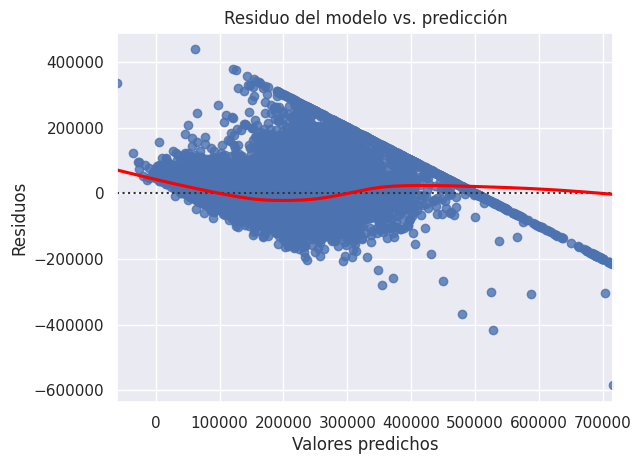

In [ ]:
# 1. Gráfico de residuos

sns.residplot(x=pred_train, y=residuos, lowess=True, line_kws={'color': 'red'})
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuo del modelo vs. predicción")
plt.show()

Los residuos no parecen distribuirse de forma aleatoria en torno a cero. Se observa un patrón.

#### Independencia de errores (autocorrelación)

La autocorrelación sugiere que los errores no son aleatorios, sino que tienen cierta dependencia del orden en que fueron tomados. Para verificar si hay autocorrelación se puede usar el test estadístico de Durbin-Watson:


* Si es cercano a 2 no hay pruebas de que haya autocorrelación.
* Si d es un valor bajo (típicamente menor que 1), existe evidencia estadística de que los residuos están autocorrelacionados positivamente.
* Si d es alto (típicamente mayor que 3), los residuos estarían autocorrelacionados negativamente.

In [ ]:
from statsmodels.stats.stattools import durbin_watson

durbin_watson_stat = durbin_watson(residuos)
print(f"Durbin-Watson: {durbin_watson_stat}")

Durbin-Watson: 1.967202026808341


* d = 1.9672 es cercano a 2 no hay pruebas de que haya autocorrelación.

#### Homoscedasticidad

Un modelo presenta homoscedasticidad cuando  la varianza de los residuos es constante (no aumenta ni disminuye con el valor predicho). Es útil el gráfico de residuos donde la dispersión debe ser constante a lo largo del rango de predicciones. Si la varianza de los errores no es constante, se dice que hay heterocedasticidad, lo cual puede afectar la validez de las pruebas estadísticas y los intervalos de confianza del modelo.


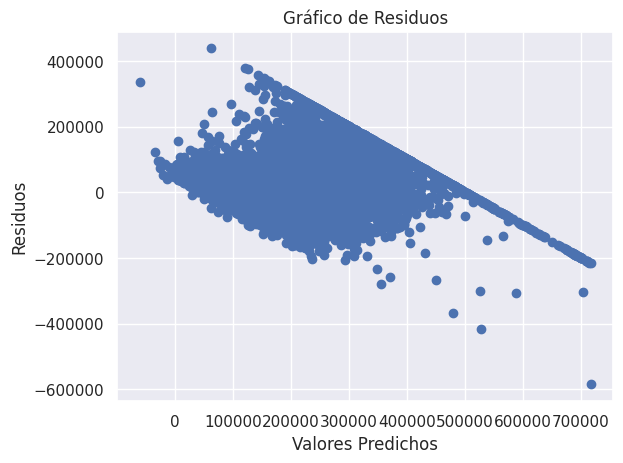

In [ ]:
# 1. Gráfico de residuos
plt.scatter(pred_train, residuos)
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.title("Gráfico de Residuos")
plt.show()



Un método visual consiste en graficar los residuos (diferencia entre los valores observados y predichos) contra los valores predichos o contra cada variable independiente. Si el gráfico muestra una forma de "cono" o una dispersión no uniforme de los residuos, sugiere heterocedasticidad.

#### Normalidad de los residuos

 Los residuos deben estar distribuidos normalmente (es relevante para inferencia estadística, no tanto para predicción). Se puede diagnosticar con Histogramas o Q-Q plot (gráfico cuantil-cuantil). Diversos tests estadísticos se han desarrollado para su detección, como la prueba de Shapiro-Wilk o el test de Jarque-Bera. Si los residuos no son normales, se puede considerar hacer una transformación de los datos o un modelo más robusto.

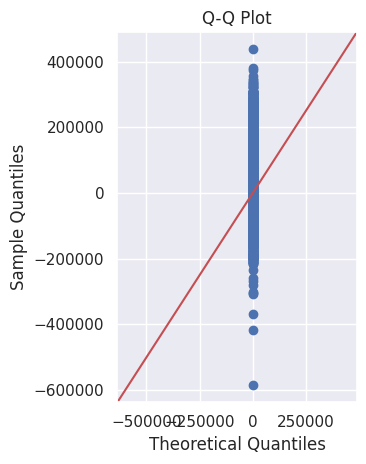

Shapiro-Wilk p-value: 4.7345988894014406e-64


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14448.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


# Q-Q plot
#stats.probplot(residuals, dist="norm", plot=plt)
#plt.title("Q-Q plot de residuos")
#plt.show()

plt.subplot(1, 2, 2)
sm.qqplot(residuos, line ='45', ax=plt.gca())
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()

# Shapiro-Wilk test
stat, p = stats.shapiro(residuos)
print(f'Shapiro-Wilk p-value: {p}')

Si los puntos del Q-Q plot se acercan a la línea diagonal, indica que los datos de la muestra siguen de cerca la distribución teórica o la otra muestra con la que se está comparando. Las desviaciones de la línea diagonal sugieren que los datos de la muestra tienen una distribución diferente a la esperada. Esto puede indicar diferentes características, como asimetría o colas pesadas.

Para el ejemplo los residuos no se distribuyen normal.

#### Ausencia de multicolinealidad

Las variables independientes no deben estar altamente correlacionadas entre sí. Se puede diagnosticar con el Factor de inflación de la varianza (VIF) . La multicolinealidad puede dificultar la interpretación de los coeficientes del modelo y aumentar la varianza de los estimadores.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = sm.add_constant(x_train_pp)  # Asegurar que X sea un DataFrame
vif_data = pd.DataFrame()
vif_data["variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

                           variable        VIF
0                             const   3.064032
1            rooms_per_house__ratio   1.328330
2                   bedrooms__ratio   1.933548
3           people_per_house__ratio   1.003676
4       cat__ocean_proximity_INLAND   2.894276
5       cat__ocean_proximity_ISLAND   1.001673
6     cat__ocean_proximity_NEAR BAY   1.547072
7   cat__ocean_proximity_NEAR OCEAN   1.176748
8              remainder__longitude  17.922362
9               remainder__latitude  19.862376
10    remainder__housing_median_age   1.164834
11         remainder__median_income   2.027673


* VIF = 1: ausencia total de colinealidad

* 1 < VIF < 5: la regresión puede verse afectada por cierta colinealidad.

* 5 < VIF < 10: la regresión puede verse altamente afectada por cierta colinealidad.

En nuestro modelo con las variables transformadas existe graves problemas de multicolinealidad. Determinar con que variable trabajar sabiendo de la relación en distrito cercano a oceano, distancia e ingresos medianos.

###🥇Métricas de rendimiento

Luego del diagnóstico, análisis de la bondad de ajuste del modelo, viene la evaluación.
Se espera llegar aquí una vez que el modelo creado es óptimo para buscar el mejor através de las siguientes métricas.

Calculando

In [ ]:
y_test_1 = y_test.values.reshape(-1, 1)
y_test_1[:5]

array([[ 47700.],
       [ 45800.],
       [500001.],
       [218600.],
       [278000.]])

In [ ]:
y_pred_1= pred.reshape(-1, 1)
y_pred_1[:5]

array([[ 80287.27492772],
       [110635.47018373],
       [209241.17043146],
       [275625.20965605],
       [253553.84899346]])

In [ ]:
import numpy as np

errors = y_test_1 - y_pred_1

# Error Cuadrático Medio (MSE)
mse_manual = np.mean(errors**2)
print("mse_manual:",mse_manual)


# Raíz del Error Cuadrático Medio (RMSE)
rmse_manual = np.sqrt(mse_manual)
print("rmse_manual:",rmse_manual)


# Error Absoluto Medio (MAE)
mae_manual = np.mean(np.abs(errors))
print("mae_manual:",mae_manual)


# R² (Coeficiente de determinación)
ss_res = np.sum((y_test_1 - y_pred_1)**2)
ss_tot = np.sum((y_test_1 - np.mean(y_test_1))**2)
r2_manual = 1 - ss_res / ss_tot
print("r2_manual:",r2_manual)

print("\n Para 5 elementos")
print("y_real: ",y_test_1[:5])
print("y_pred: ",y_pred_1[:5])
print("Residuos:", errors[:5])
print("mse_manual para 5:",np.mean(errors[:5]**2))
print("rmse_manual para 5:",np.sqrt(np.mean(errors[:5]**2)))
print("mae_manual para 5:", np.mean(np.abs(errors[:5])))
ss_res = np.sum((y_test_1[:5] - y_pred_1[:5])**2)
ss_tot = np.sum((y_test_1[:5] - np.mean(y_test_1[:5]))**2)
r2_manual = 1 - ss_res / ss_tot
print("r2_manual para 5:",r2_manual)



mse_manual: 5474732764.026191
rmse_manual: 73991.43709934407
mae_manual: 52248.386808733085
r2_manual: 0.5828902498724569

 Para 5 elementos
y_real:  [[ 47700.]
 [ 45800.]
 [500001.]
 [218600.]
 [278000.]]
y_pred:  [[ 80287.27492772]
 [110635.47018373]
 [209241.17043146]
 [275625.20965605]
 [253553.84899346]]
Residuos: [[-32587.27492772]
 [-64835.47018373]
 [290759.82956854]
 [-57025.20965605]
 [ 24446.15100654]]
mse_manual para 5: 18731267201.447243
rmse_manual para 5: 136862.219773929
mae_manual para 5: 93930.78706851495
r2_manual para 5: 0.3394242220458039


Utilizando librería

Para más información [métricas de regresión](https://scikit-learn.org/stable/api/sklearn.metrics.html)


In [ ]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

# Supongamos que ya tenés y_test (valores reales) y y_pred (predicciones)
mse = mean_squared_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)  # raíz del MSE
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
r2_ajus = 1 - ((1-r2)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1))
#

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")
print(f"R²ajustado: {r2_ajus:.2f}")

MSE: 5474732764.03
RMSE: 73991.44
MAE: 52248.39
R²: 0.58
R²ajustado: 0.58


* El MSE penaliza más los errores grandes porque eleva al cuadrado las diferencias. El modelo presenta valores atípicos que afectan los resultados.
* La raíz del Error Cuadrático Medio (RMSE) es 73,991.44. En promedio, el modelo se equivoca en ±73,991 dólares al predecir el valor mediano de una vivienda.
*  El MAE una métrica más robusta que el MSE frente a valores atípicos. Indica que el error promedio absoluto del modelo es de 52,248 unidades monetarias. Comparado con el RMSE, el MAE es más bajo, lo que sugiere que hay errores grandes que están inflando el RMSE.
* Por R², el modelo explica el 58% de la variabilidad en median_house_value. Aún queda más del 50% sin explicar.



#### Conclusiones

El modelo podría beneficiarse de:

* Selección de características
* Manejo de valores atípicos.
* Algún tipo de regularización o modelo no lineal, si las relaciones no son estrictamente lineales.

## Anexo


Ver ejemplo  https://scikit-learn.org/stable/auto_examples/linear_model/plot_ols.html

Mean squared error: 2548.07
Coefficient of determination: 0.47


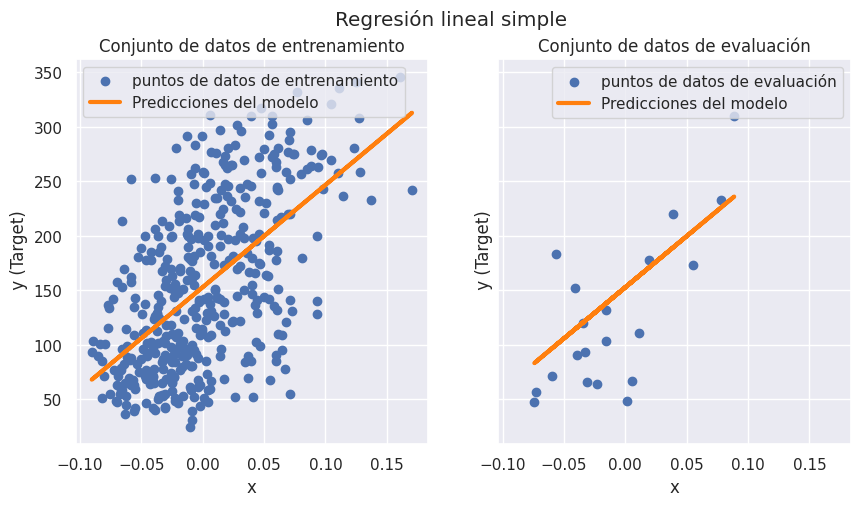

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X, y = load_diabetes(return_X_y=True)
X = X[:, [2]]  # Use only one feature
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)
regressor = LinearRegression().fit(X_train, y_train)
from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train, y_train, label="puntos de datos de entrenamiento")
ax[0].plot(
    X_train,
    regressor.predict(X_train),
    linewidth=3,
    color="tab:orange",
    label="Predicciones del modelo",
)
ax[0].set(xlabel="x", ylabel=" y (Target)", title="Conjunto de datos de entrenamiento")
ax[0].legend()

ax[1].scatter(X_test, y_test, label="puntos de datos de evaluación")
ax[1].plot(X_test, y_pred, linewidth=3, color="tab:orange", label="Predicciones del modelo")
ax[1].set(xlabel="x", ylabel=" y (Target)", title="Conjunto de datos de evaluación")
ax[1].legend()

fig.suptitle("Regresión lineal simple")

plt.show()

Para más ejemplos: https://cienciadedatos.net/documentos/py10-regresion-lineal-python